# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [89]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [90]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


In [91]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.3.3
matplotlib version: 3.9.4
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [92]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()
df_test = pd.read_parquet('datasets/trip_records/2023-1.parquet')
df_test.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [93]:
df_test.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [94]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/Users/neerajaithak/Downloads/Datasets and Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_data = pd.read_parquet(file_path)



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour

        sampled_data = (
             month_data
             .groupby(['pickup_date', 'pickup_hour'], group_keys=False)
             .apply(lambda x: x.sample(frac=0.05, random_state=42))
           )
        sampled_data = sampled_data.drop(columns=['pickup_date'])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)
        print(f"{file_name}: {len(sampled_data):,} rows sampled")
       

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
print(f"\nTotal rows seen in the combined dataset: {len(df):,}")

2023-12.parquet: 166,709 rows sampled
2023-6.parquet: 162,910 rows sampled
2023-7.parquet: 174,068 rows sampled
2023-5.parquet: 144,458 rows sampled
2023-11.parquet: 165,133 rows sampled
2023-10.parquet: 174,255 rows sampled
2023-4.parquet: 139,641 rows sampled
2023-1.parquet: 152,087 rows sampled
2023-8.parquet: 143,782 rows sampled
2023-9.parquet: 140,875 rows sampled
2023-2.parquet: 168,696 rows sampled
2023-3.parquet: 163,786 rows sampled

Total rows seen in the combined dataset: 1,896,400


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [95]:
# Store the df in csv/parquet
# df.to_parquet('')

new_combined_sample_data = 'datasets/sampled_nyc_taxi_2023.parquet'
df.to_parquet(new_combined_sample_data, index=False)
print(f"Saved succesfully!")
print(f"Shape: {df.shape}")

Saved succesfully!
Shape: (1896400, 21)


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [96]:
# Load the new data file
df = pd.read_parquet(new_combined_sample_data)
print(f"DataFranme's rows and cols: {df.shape}")

DataFranme's rows and cols: (1896400, 21)


In [97]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,airport_fee
0,2,2023-11-30 23:58:12,2023-12-01 00:06:58,1.0,1.31,1.0,N,163,162,1,...,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,23,NaN
1,2,2023-11-30 23:58:35,2023-12-01 00:06:32,1.0,1.22,1.0,N,161,229,1,...,1.0,0.5,1.43,0.0,1.0,15.73,2.5,0.0,23,NaN
2,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,1.0,0.5,5.66,0.0,1.0,33.96,2.5,0.0,0,NaN
3,2,2023-12-01 00:38:48,2023-12-01 01:01:55,NaN,4.79,NaN,None,231,61,0,...,0.0,0.5,3.00,0.0,1.0,29.43,NaN,NaN,0,NaN
4,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,1.0,0.5,3.14,0.0,1.0,18.84,2.5,0.0,0,NaN


In [98]:
# df.info()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [99]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count            64874
trip_distance                  0
RatecodeID                 64874
store_and_fwd_flag         64874
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       64874
Airport_fee               213357
pickup_hour                    0
airport_fee              1747917
dtype: int64

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [100]:
# Fix the index and drop any columns that are not needed

df = df.reset_index(drop=True)
df.index
#irrelevant colm
df = df.drop(columns=['store_and_fwd_flag'])

print(f"Shape after dropping: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape after dropping: (1896400, 20)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'airport_fee']


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [101]:
# Combine the two airport fee columns
# Checking both colms
print("Airport_fee missing:", df['Airport_fee'].isnull().sum())
print("airport_fee missing:", df['airport_fee'].isnull().sum())

#taking values from whichever has data
df['airport_fee'] = df['Airport_fee'].combine_first(df['airport_fee'])
print(df['airport_fee'].isnull().sum())


# Dropping the duplicate column
df = df.drop(columns=['Airport_fee'])

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Airport_fee missing: 213357
airport_fee missing: 1747917
64874
Shape: (1896400, 19)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'pickup_hour', 'airport_fee']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [102]:
# check where values of fare amount are negative

neg_fare = df[df['fare_amount'] < 0]
print(f"Rows with negative fare_amount: {len(neg_fare)}")

Rows with negative fare_amount: 0


Did you notice something different in the `RatecodeID` column for above records?

In [103]:
# Analyse RatecodeID for the negative fare amounts

print("No negative fare values found in sample for RatecodeID analysis")

No negative fare values found in sample for RatecodeID analysis


In [104]:
# Find which columns have negative values

monetary_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 
                 'tolls_amount', 'improvement_surcharge', 'total_amount', 
                 'congestion_surcharge', 'airport_fee']

for col in monetary_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values (min = {df[col].min():.2f})")
    else:
        print(f"{col}: no negative values")

fare_amount: no negative values
extra: 3 negative values (min = -2.50)
mta_tax: 73 negative values (min = -0.50)
tip_amount: no negative values
tolls_amount: no negative values
improvement_surcharge: 78 negative values (min = -1.00)
total_amount: 78 negative values (min = -5.75)
congestion_surcharge: 56 negative values (min = -2.50)
airport_fee: 15 negative values (min = -1.75)


In [105]:
# fix these negative values
colmns_with_negatives = ['extra', 'mta_tax', 'improvement_surcharge', 
                       'total_amount', 'congestion_surcharge', 'airport_fee']

for col in colmns_with_negatives:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        df[col] = df[col].abs()
        print(f"Fixed {neg_count} negative values in {col}")

print("\nVerification: Negative values remaining:")
for col in colmns_with_negatives:
    print(f"  {col}: {(df[col] < 0).sum()}")


Fixed 3 negative values in extra
Fixed 73 negative values in mta_tax
Fixed 78 negative values in improvement_surcharge
Fixed 78 negative values in total_amount
Fixed 56 negative values in congestion_surcharge
Fixed 15 negative values in airport_fee

Verification: Negative values remaining:
  extra: 0
  mta_tax: 0
  improvement_surcharge: 0
  total_amount: 0
  congestion_surcharge: 0
  airport_fee: 0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [106]:
# Find the proportion of missing values in each column

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

                      Missing Count  Missing %
passenger_count               64874       3.42
RatecodeID                    64874       3.42
congestion_surcharge          64874       3.42
airport_fee                   64874       3.42


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [107]:
# Display the rows with null values

print("Before:")
print(f"Null values: {df['passenger_count'].isnull().sum()}")
print(f"Zero values: {(df['passenger_count'] == 0).sum()}")
print(df['passenger_count'].value_counts().sort_index())

# Impute NaN values in 'passenger_count'
mode_pax = df['passenger_count'].mode()[0]
print(f"\nMode (most common passenger count): {mode_pax}")
df['passenger_count'] = df['passenger_count'].fillna(mode_pax)

Before:
Null values: 64874
Zero values: 29681
passenger_count
0.0      29681
1.0    1377224
2.0     277298
3.0      69034
4.0      38537
5.0      23871
6.0      15860
7.0          5
8.0         11
9.0          5
Name: count, dtype: int64

Mode (most common passenger count): 1.0


Did you find zeroes in passenger_count? Handle these.

In [108]:
# Also fixing zero passenger counts (makes no sense)
df['passenger_count'] = df['passenger_count'].replace(0, mode_pax)

print(f"\nAfter fixing:")
print(f"Null values: {df['passenger_count'].isnull().sum()}")
print(f"Zero values: {(df['passenger_count'] == 0).sum()}")


After fixing:
Null values: 0
Zero values: 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [109]:
# Fix missing values in 'RatecodeID'
print(f"Null values: {df['RatecodeID'].isnull().sum()}")
print("\nRatecodeID distribution:")
print(df['RatecodeID'].value_counts().sort_index())

# Impute with mode
mode_rate = df['RatecodeID'].mode()[0]
print(f"\nMode (most common RatecodeID): {mode_rate}")

df['RatecodeID'] = df['RatecodeID'].fillna(mode_rate)

print(f"\nNull values remaining: {df['RatecodeID'].isnull().sum()}")

Null values: 64874

RatecodeID distribution:
RatecodeID
1.0     1729259
2.0       71670
3.0        6124
4.0        3723
5.0       10275
6.0           3
99.0      10472
Name: count, dtype: int64

Mode (most common RatecodeID): 1.0

Null values remaining: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [110]:
# handle null values in congestion_surcharge

print(f"Null values: {df['congestion_surcharge'].isnull().sum()}")
print("\nCongestion distrbution:")
print(df['congestion_surcharge'].value_counts().sort_index())

# Missing so fill with 0 (logical fix)
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print(f"\nNull values remaining: {df['congestion_surcharge'].isnull().sum()}")

Null values: 64874

Congestion distrbution:
congestion_surcharge
0.0     140897
0.5          1
2.5    1690628
Name: count, dtype: int64

Null values remaining: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [111]:
# Handle any remaining missing values

#Found in airport_fees
print(f"Null values: {df['airport_fee'].isnull().sum()}")
print("\nairport_fee distribution:")
print(df['airport_fee'].value_counts().sort_index())

#replace with 0
df['airport_fee'] = df['airport_fee'].fillna(0)

print(f"\nNull values remaining: {df['airport_fee'].isnull().sum()}")

#Check all colms once
print("\nFINAL MISSING VALUES CHECK")
print(df.isnull().sum())

Null values: 64874

airport_fee distribution:
airport_fee
0.00    1670564
1.00          1
1.25      39827
1.75     121134
Name: count, dtype: int64

Null values remaining: 0

FINAL MISSING VALUES CHECK
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
pickup_hour              0
airport_fee              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [112]:
# Describe the data and check if there are any potential outliers present
print(df.describe().round(2))
# Check for potential out of place values in various columns

# Highlight suspicious extreme values
print("\nSUS VALUES")
print(f"Max trip_distance  : {df['trip_distance'].max()} miles")
print(f"Max fare_amount    : ${df['fare_amount'].max()}")
print(f"Max total_amount   : ${df['total_amount'].max()}")
print(f"Max passenger_count: {int(df['passenger_count'].max())}")
print(f"Min payment_type   : {df['payment_type'].min()}")
print(f"Max RatecodeID     : {df['RatecodeID'].max()}")
print(f"Max tip_amount     : ${df['tip_amount'].max()} can be possible (boderline)")

         VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  1896400.00                     1896400                     1896400   
mean         1.73  2023-07-02 19:59:52.930796  2023-07-02 20:17:18.919563   
min          1.00         2022-12-31 23:51:30         2022-12-31 23:56:06   
25%          1.00  2023-04-02 16:10:08.750000  2023-04-02 16:27:43.500000   
50%          2.00  2023-06-27 15:44:22.500000         2023-06-27 16:01:15   
75%          2.00         2023-10-06 19:37:45         2023-10-06 19:53:39   
max          6.00         2023-12-31 23:57:51         2024-01-01 20:50:55   
std          0.45                         NaN                         NaN   

       passenger_count  trip_distance  RatecodeID  PULocationID  DOLocationID  \
count       1896400.00     1896400.00  1896400.00    1896400.00    1896400.00   
mean              1.37           3.86        1.61        165.28        164.05   
min               1.00           0.00        1.00          1.00

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [113]:
# remove passenger_count > 6
print(f"Rows with passenger_count > 6: {(df['passenger_count'] > 6).sum()}")
df = df[df['passenger_count'] <= 6].reset_index(drop=True)
print(f"Shape after removal: {df.shape}")

Rows with passenger_count > 6: 21
Shape after removal: (1896379, 19)


In [115]:
# Continue with outlier handling

# Check each outlier condition first
print(" OUTLIER COUNTS ")
print(f"1. Distance > 250 miles: {(df['trip_distance'] > 250).sum()}")
print(f"2. Distance < 0.1mi AND fare > $100: {((df['trip_distance'] < 0.1) & (df['fare_amount'] > 100)).sum()}")
print(f"3. Zero distance, zero fare, different zones: {((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])).sum()}")
print(f"4. payment_type == 0: {(df['payment_type'] == 0).sum()}")
print(f"\nShape before: {df.shape}")

 OUTLIER COUNTS 
1. Distance > 250 miles: 46
2. Distance < 0.1mi AND fare > $100: 682
3. Zero distance, zero fare, different zones: 63
4. payment_type == 0: 64874

Shape before: (1896379, 19)


In [116]:
# Remove outliers one by one
df = df[df['trip_distance'] <= 250]
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 100))]
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]
df = df[df['payment_type'] != 0]

df = df.reset_index(drop=True)
print(f"Final shape after outlier removal: {df.shape}")

Final shape after outlier removal: (1830749, 19)


In [117]:
#Check if outlieres are gone
print(df.describe().round(2))

         VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  1830749.00                     1830749                     1830749   
mean         1.74  2023-07-01 21:11:32.042570  2023-07-01 21:28:54.351114   
min          1.00         2022-12-31 23:51:30         2022-12-31 23:56:06   
25%          1.00         2023-04-01 20:06:47         2023-04-01 20:21:21   
50%          2.00         2023-06-26 08:15:19         2023-06-26 08:30:51   
75%          2.00         2023-10-05 19:16:55         2023-10-05 19:34:40   
max          2.00         2023-12-31 23:57:51         2024-01-01 20:50:55   
std          0.44                         NaN                         NaN   

       passenger_count  trip_distance  RatecodeID  PULocationID  DOLocationID  \
count       1830749.00     1830749.00  1830749.00    1830749.00    1830749.00   
mean              1.39           3.45        1.63        165.45        164.32   
min               1.00           0.00        1.00          1.00

In [118]:
# Remove extreme fare amounts (over $1000 )
print(f"Fares over $1000: {(df['fare_amount'] > 1000).sum()}")
df = df[df['fare_amount'] <= 1000]

# Remove extreme total amounts
print(f"Total amount over $1000: {(df['total_amount'] > 1000).sum()}")
df = df[df['total_amount'] <= 1000]

df = df.reset_index(drop=True)
print(f"\nShape after fixing: {df.shape}")
print(f"Max fare_amount: ${df['fare_amount'].max()}")
print(f"Max total_amount: ${df['total_amount'].max()}")

Fares over $1000: 2
Total amount over $1000: 0

Shape after fixing: (1830747, 19)
Max fare_amount: $786.3
Max total_amount: $790.55


In [119]:
#Final check if outlieres are gone
print(df.describe().round(2))

         VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  1830747.00                     1830747                     1830747   
mean         1.74  2023-07-01 21:11:26.695203  2023-07-01 21:28:48.995326   
min          1.00         2022-12-31 23:51:30         2022-12-31 23:56:06   
25%          1.00         2023-04-01 20:06:43  2023-04-01 20:21:08.500000   
50%          2.00         2023-06-26 08:15:14         2023-06-26 08:30:36   
75%          2.00         2023-10-05 19:17:00         2023-10-05 19:34:42   
max          2.00         2023-12-31 23:57:51         2024-01-01 20:50:55   
std          0.44                         NaN                         NaN   

       passenger_count  trip_distance  RatecodeID  PULocationID  DOLocationID  \
count       1830747.00     1830747.00  1830747.00    1830747.00    1830747.00   
mean              1.39           3.45        1.63        165.45        164.32   
min               1.00           0.00        1.00          1.00

In [120]:
# Do any columns need standardising?
#yes we do before EDA
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create derived columns needed for analysis
df['trip_duration']      = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['pickup_month']       = df['tpep_pickup_datetime'].dt.month
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['pickup_day_name']    = df['tpep_pickup_datetime'].dt.day_name()

# Standardise data types
df['passenger_count'] = df['passenger_count'].astype(int)
df['RatecodeID']      = df['RatecodeID'].astype(int)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)


Shape: (1830747, 23)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'pickup_hour', 'airport_fee', 'trip_duration', 'pickup_month', 'pickup_day_of_week', 'pickup_day_name']

Data types:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
imp

In [121]:
#Saving cleaned data
cleaned_data = 'datasets/clean_nyc_taxi_2023.parquet'
df.to_parquet(cleaned_data, index=False)
print(f"Clean data saved. Let's go! Shape: {df.shape}")

Clean data saved. Let's go! Shape: (1830747, 23)


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical (Nominal)
* `tpep_pickup_datetime`: Datetime (Temporal)
* `tpep_dropoff_datetime`: Datetime (Temporal)
* `passenger_count`: Categorical (Discrete)
* `trip_distance`: Numerical (Continuous)
* `RatecodeID`: Categorical (Nominal)
* `PULocationID`: Categorical (Nominal)
* `DOLocationID`: Categorical (Nominal)
* `payment_type`: Categorical (Nominal)
* `pickup_hour`: Categorical (Ordinal)
* `trip_duration`: Numerical (Continuous)

The monetary parameters are Numerical (Continuous), they represent actual measurable amounts where mathematical operations like average and sum make sense.


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount` — Numerical (Continuous)
* `extra` — Numerical (Continuous)
* `mta_tax` — Numerical (Continuous)
* `tip_amount` — Numerical (Continuous)
* `tolls_amount` — Numerical (Continuous)
* `improvement_surcharge` — Numerical (Continuous)
* `total_amount` — Numerical (Continuous)
* `congestion_surcharge` — Numerical (Continuous)
* `airport_fee` — Numerical (Continuous)
  
These represent actual measurable amounts — averaging, summing and comparing them makes mathematical sense.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

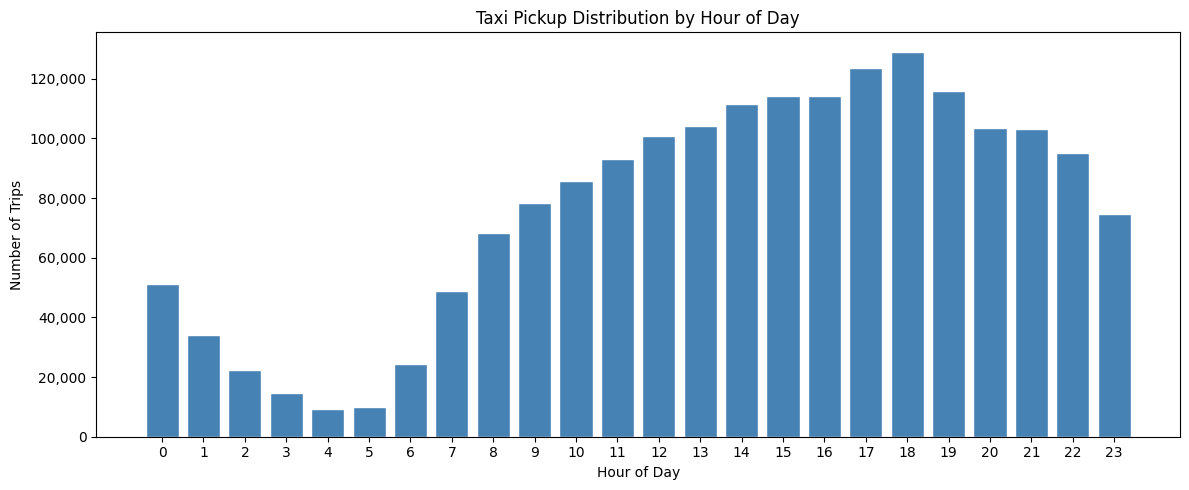

Busiest hour: 18:00
 pickup_hour  trip_count
          18      129133
          17      123523
          19      115888
          15      114267
          16      114251


In [122]:
# Find and show the hourly trends in taxi pickups

# Hourly trends
hourly_trips = df.groupby('pickup_hour').size().reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_trips['pickup_hour'], hourly_trips['trip_count'], 
       color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')
ax.set_title('Taxi Pickup Distribution by Hour of Day')
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"Busiest hour: {hourly_trips.loc[hourly_trips['trip_count'].idxmax(), 'pickup_hour']}:00")
print(hourly_trips.nlargest(5, 'trip_count').to_string(index=False))


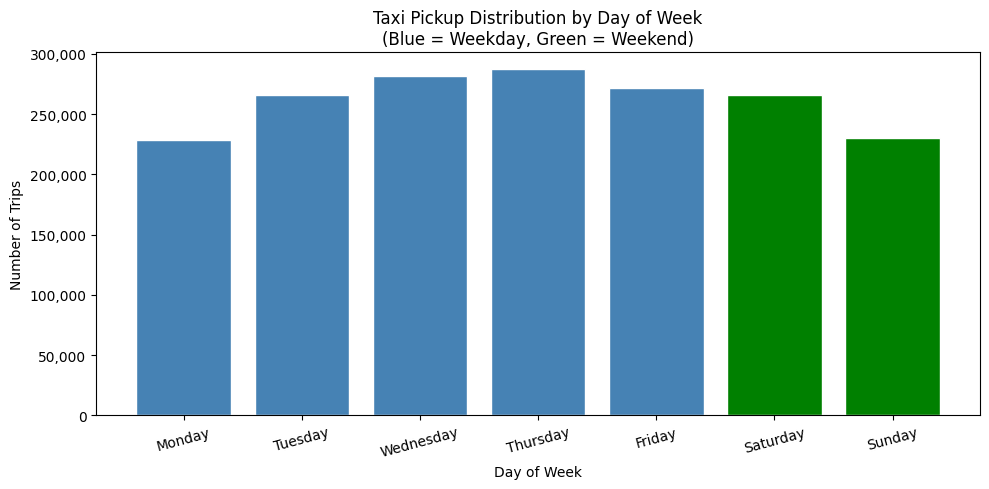

pickup_day_name  trip_count
         Monday      228878
        Tuesday      265870
      Wednesday      281482
       Thursday      287181
         Friday      271508
       Saturday      265758
         Sunday      230070


In [125]:
# Find and show the daily trends in taxi pickups (days of the week)

# Daily trends
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_trips = df.groupby('pickup_day_name').size().reindex(DAY_ORDER).reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if d not in ['Saturday', 'Sunday'] else 'green' for d in DAY_ORDER]
ax.bar(daily_trips['pickup_day_name'], daily_trips['trip_count'], 
       color=colors, edgecolor='white')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Trips')
ax.set_title('Taxi Pickup Distribution by Day of Week\n(Blue = Weekday, Green = Weekend)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(daily_trips.to_string(index=False))

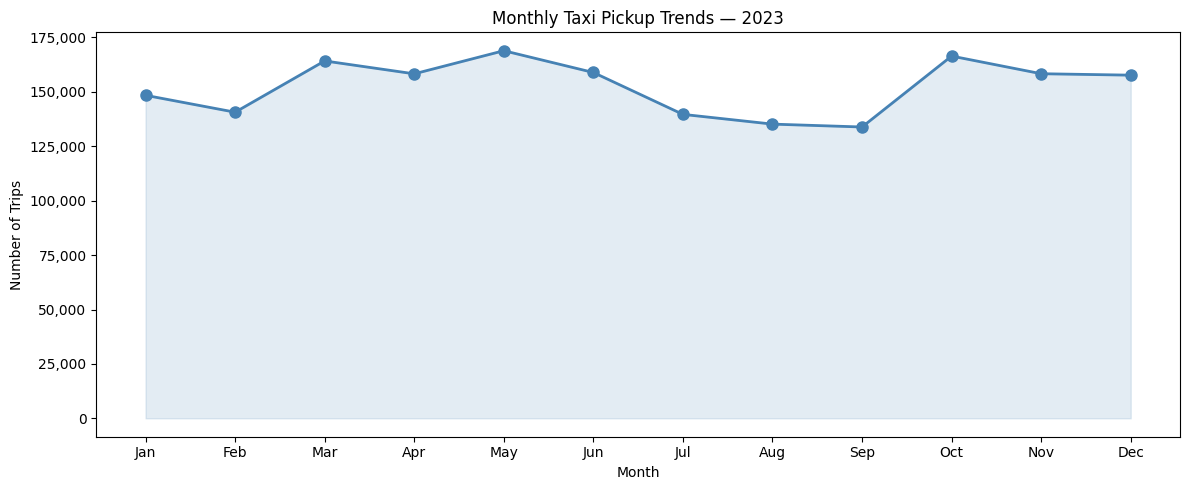

month_name  trip_count
       Jan      148436
       Feb      140670
       Mar      164232
       Apr      158305
       May      168926
       Jun      158919
       Jul      139676
       Aug      135197
       Sep      133874
       Oct      166466
       Nov      158353
       Dec      157693


In [126]:
# Show the monthly trends in pickups

# Monthly pickup trends
MONTH_NAMES = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_trips = df.groupby('pickup_month').size().reset_index(name='trip_count')
monthly_trips['month_name'] = monthly_trips['pickup_month'].map(MONTH_NAMES)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_trips['month_name'], monthly_trips['trip_count'], 
        marker='o', linewidth=2, markersize=8, color='steelblue')
ax.fill_between(range(12), monthly_trips['trip_count'], alpha=0.15, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.set_title('Monthly Taxi Pickup Trends — 2023')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(monthly_trips[['month_name', 'trip_count']].to_string(index=False))

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

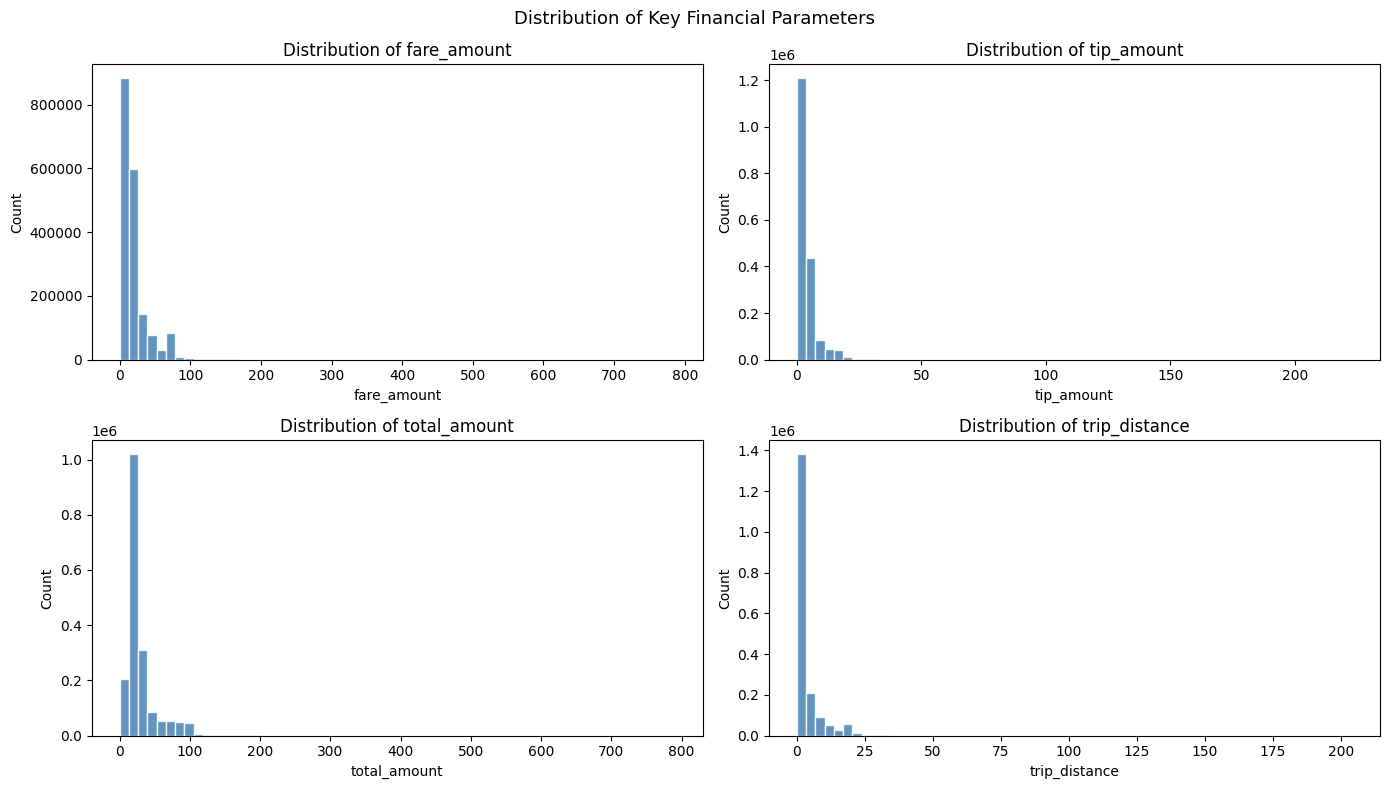

fare_amount: 575 zeros
tip_amount: 409959 zeros
total_amount: 255 zeros
trip_distance: 22337 zeros


In [128]:
# Analyse the above parameters

# stats
df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe().round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']):
    ax.hist(df[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key Financial Parameters', fontsize=13)
plt.tight_layout()
plt.show()

# Count zeros
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [132]:
# Create a df with non zero entries for the selected parameters.

# tip_amount kept as >= 0 since cash trips legitmately show 0
df_nz = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

print(f"Original df : {len(df):,} rows")
print(f"Non-zero df : {len(df_nz):,} rows")
print(f"Rows rmd: {len(df) - len(df_nz):,}")

Original df : 1,830,747 rows
Non-zero df : 1,808,094 rows
Rows rmd: 22,653


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

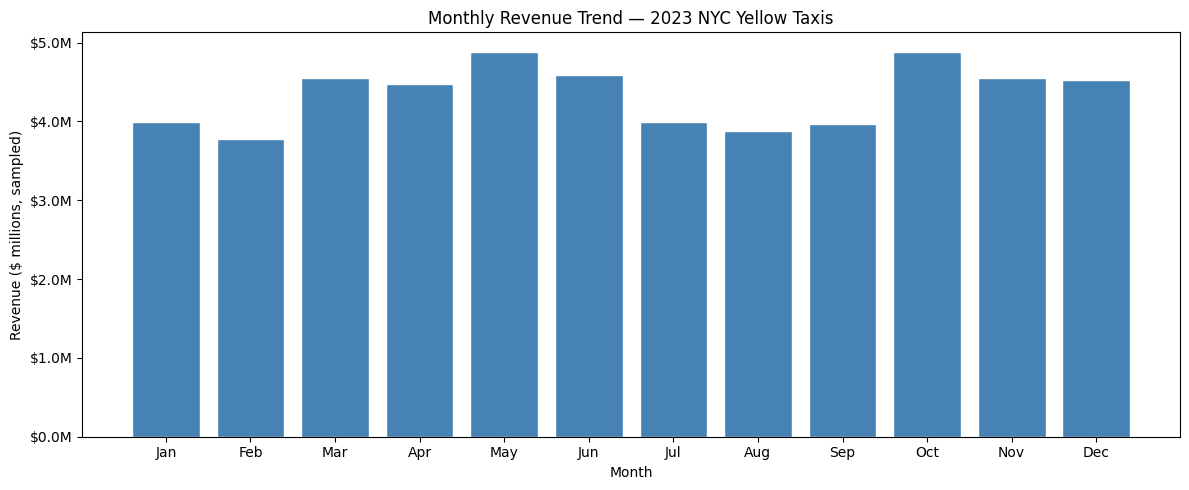

month_name  total_amount
       Jan    3994908.35
       Feb    3776271.33
       Mar    4555015.36
       Apr    4471619.89
       May    4873614.04
       Jun    4583737.95
       Jul    3986280.94
       Aug    3879802.63
       Sep    3960604.70
       Oct    4885017.00
       Nov    4549367.36
       Dec    4528255.72


In [133]:
# Group data by month and analyse monthly revenue

monthly_rev = df_nz.groupby('pickup_month')['total_amount'].sum().reset_index()
monthly_rev['month_name'] = monthly_rev['pickup_month'].map(MONTH_NAMES)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_rev['month_name'], monthly_rev['total_amount'] / 1e6,
              color='steelblue', edgecolor='white')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($ millions, sampled)')
ax.set_title('Monthly Revenue Trend — 2023 NYC Yellow Taxis')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.tight_layout()
plt.show()

print(monthly_rev[['month_name', 'total_amount']].to_string(index=False))

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

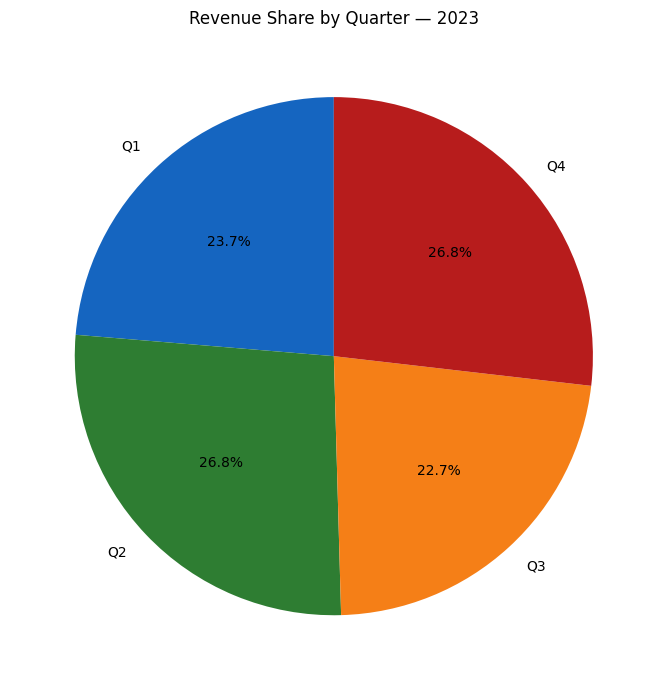

Quarterly Revenue Share:
  Q1: 23.68%
  Q2: 26.76%
  Q3: 22.72%
  Q4: 26.83%


In [134]:
# Calculate proportion of each quarter

df_nz['quarter'] = df_nz['tpep_pickup_datetime'].dt.quarter

quarterly_rev = df_nz.groupby('quarter')['total_amount'].sum()
quarterly_pct = (quarterly_rev / quarterly_rev.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(quarterly_rev, 
       labels=[f'Q{q}' for q in quarterly_rev.index],
       autopct='%1.1f%%', 
       startangle=90,
       colors=['#1565C0', '#2E7D32', '#F57F17', '#B71C1C'])
ax.set_title('Revenue Share by Quarter — 2023')
plt.tight_layout()
plt.show()

print('Quarterly Revenue Share:')
for q, pct in quarterly_pct.items():
    print(f'  Q{q}: {pct}%')


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

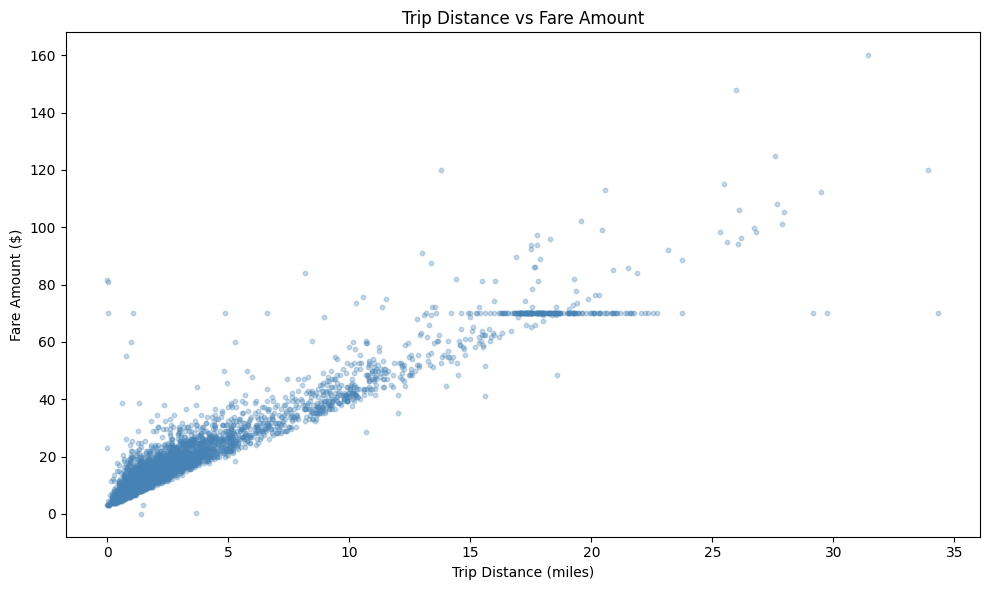

Correlation between trip_distance and fare_amount: 0.9452


In [135]:
# Show how trip fare is affected by distance

# Sample for scatter plot to avoid overploting
plot_df = df_nz[df_nz['trip_distance'] <= 40].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_df['trip_distance'], plot_df['fare_amount'],
           alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Fare Amount ($)')
ax.set_title('Trip Distance vs Fare Amount')
plt.tight_layout()
plt.show()

corr = df_nz[['trip_distance', 'fare_amount']].corr().loc['trip_distance', 'fare_amount']
print(f'Correlation between trip_distance and fare_amount: {corr:.4f}')

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

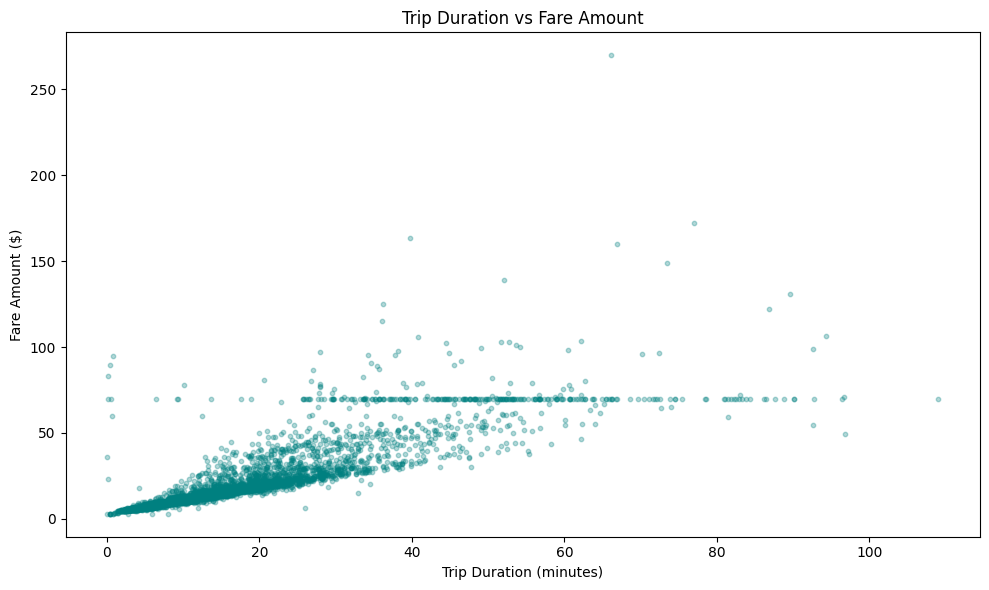

Correlation between trip_duration and fare_amount: 0.2767


In [136]:
# Show relationship between fare and trip duration
plot_dur = df_nz[df_nz['trip_duration'] <= 120].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_dur['trip_duration'], plot_dur['fare_amount'],
           alpha=0.3, s=10, color='teal')
ax.set_xlabel('Trip Duration (minutes)')
ax.set_ylabel('Fare Amount ($)')
ax.set_title('Trip Duration vs Fare Amount')
plt.tight_layout()
plt.show()

corr = df_nz[['trip_duration', 'fare_amount']].corr().loc['trip_duration', 'fare_amount']
print(f'Correlation between trip_duration and fare_amount: {corr:.4f}')


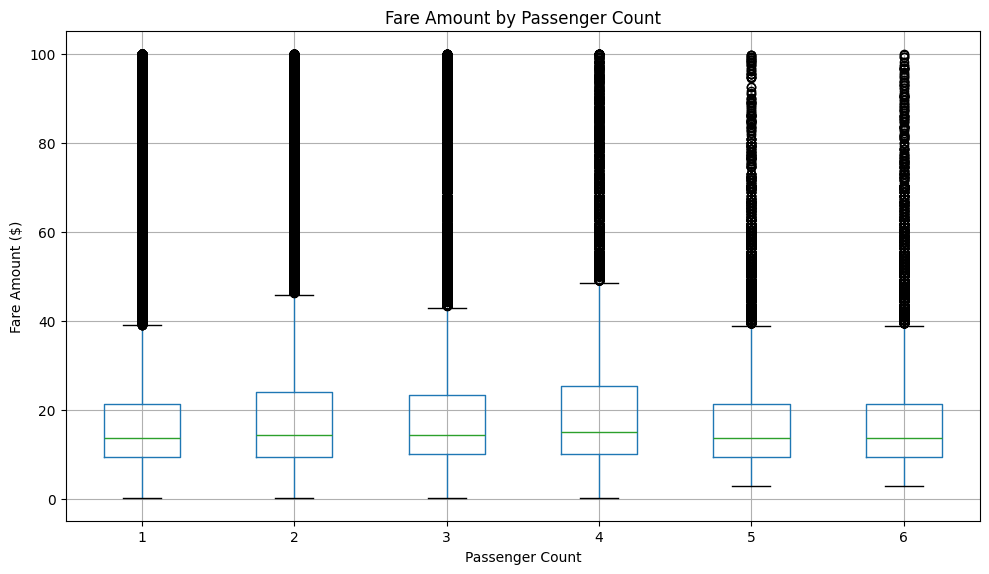

Correlation between passenger_count and fare_amount: 0.0424

Avg fare by passenger count:
passenger_count
1    18.99
2    22.03
3    21.71
4    23.01
5    18.83
6    19.08
Name: fare_amount, dtype: float64


In [138]:
# Show relationship between fare and number of passengers

fig, ax = plt.subplots(figsize=(10, 6))
df_nz[df_nz['fare_amount'] <= 100].boxplot(
    column='fare_amount', by='passenger_count', ax=ax)
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Fare Amount ($)')
ax.set_title('Fare Amount by Passenger Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

corr = df_nz[['passenger_count', 'fare_amount']].corr().loc['passenger_count', 'fare_amount']
print(f'Correlation between passenger_count and fare_amount: {corr:.4f}')
print('\nAvg fare by passenger count:')
print(df_nz.groupby('passenger_count')['fare_amount'].mean().round(2))

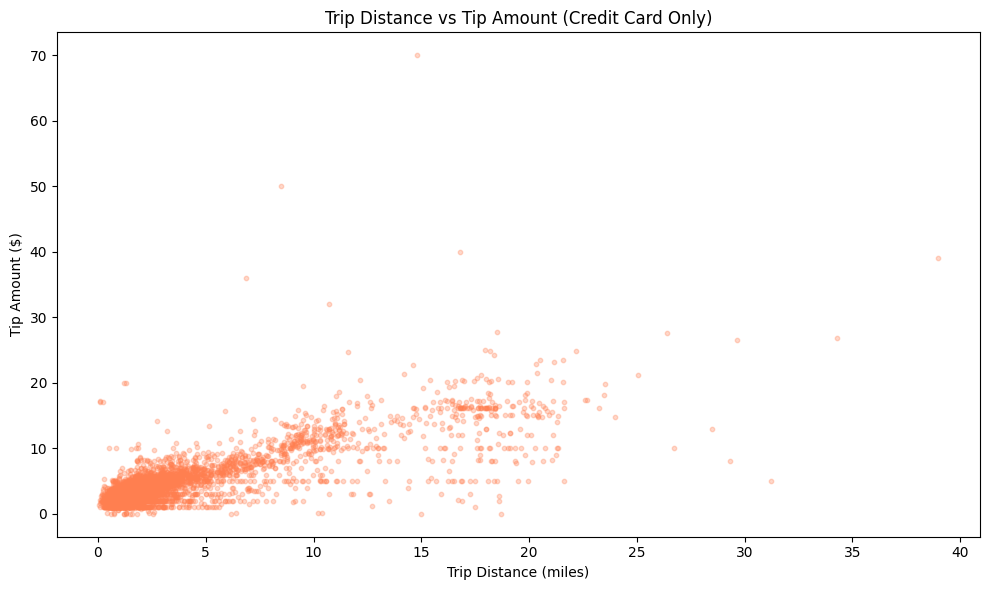

Correlation between trip_distance and tip_amount: 0.7997


In [139]:
# Show relationship between tip and trip distance
# Only credit card trips record tips
tip_cc = df_nz[(df_nz['payment_type'] == 1) & (df_nz['tip_amount'] > 0)]
plot_tip = tip_cc[tip_cc['trip_distance'] <= 40].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_tip['trip_distance'], plot_tip['tip_amount'],
           alpha=0.3, s=10, color='coral')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Tip Amount ($)')
ax.set_title('Trip Distance vs Tip Amount (Credit Card Only)')
plt.tight_layout()
plt.show()

corr = tip_cc[['trip_distance', 'tip_amount']].corr().loc['trip_distance', 'tip_amount']
print(f'Correlation between trip_distance and tip_amount: {corr:.4f}')


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

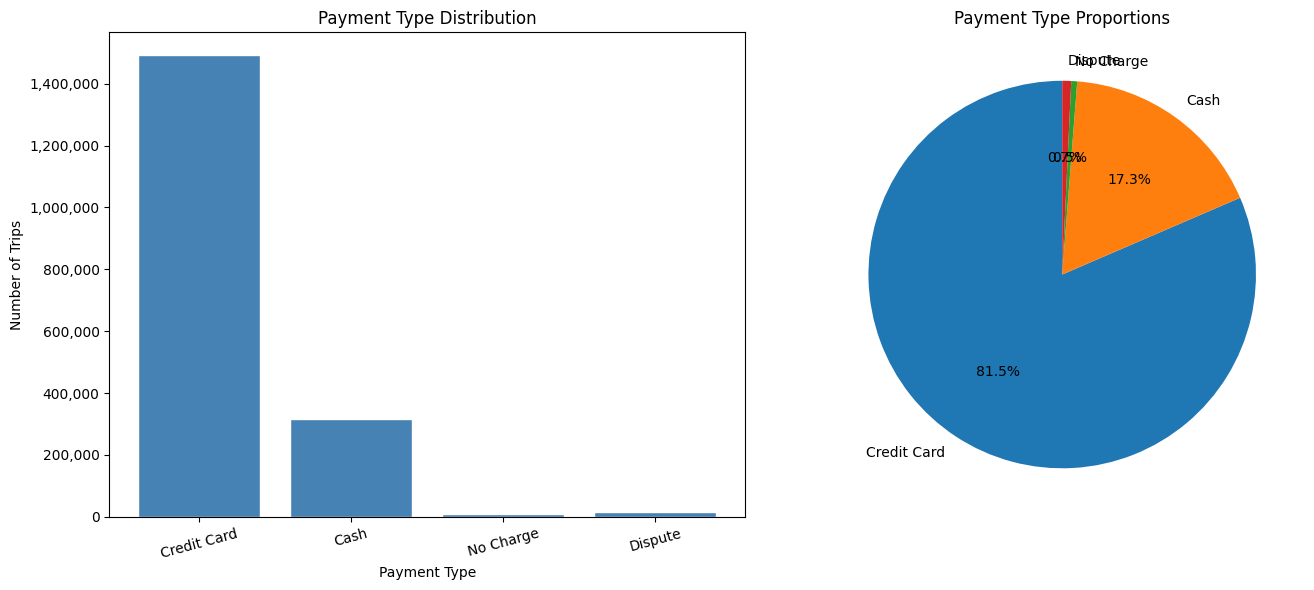

Credit Card    1491760
Cash            316336
No Charge         9000
Dispute          13651
Name: count, dtype: int64


In [140]:
# Analyse the distribution of different payment types (payment_type).
pay_labels = {1:'Credit Card', 2:'Cash', 3:'No Charge', 4:'Dispute'}
pay_counts = df['payment_type'].value_counts().sort_index()
pay_counts.index = [pay_labels.get(i, str(i)) for i in pay_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(pay_counts.index, pay_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Trips')
axes[0].set_title('Payment Type Distribution')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(pay_counts.values, labels=pay_counts.index, 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Payment Type Proportions')

plt.tight_layout()
plt.show()

print(pay_counts)



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [142]:
# import geopandas as gpd
import geopandas as gpd

# Path to taxi zones shapefile
ZONES_PATH = 'datasets/taxi_zones/taxi_zones.shp'

zones = gpd.read_file(ZONES_PATH)
print(f'Zones GeoDataFrame shape: {zones.shape}')
print(f'Columns: {zones.columns.tolist()}')
zones.head()

Zones GeoDataFrame shape: (263, 7)
Columns: ['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry']


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

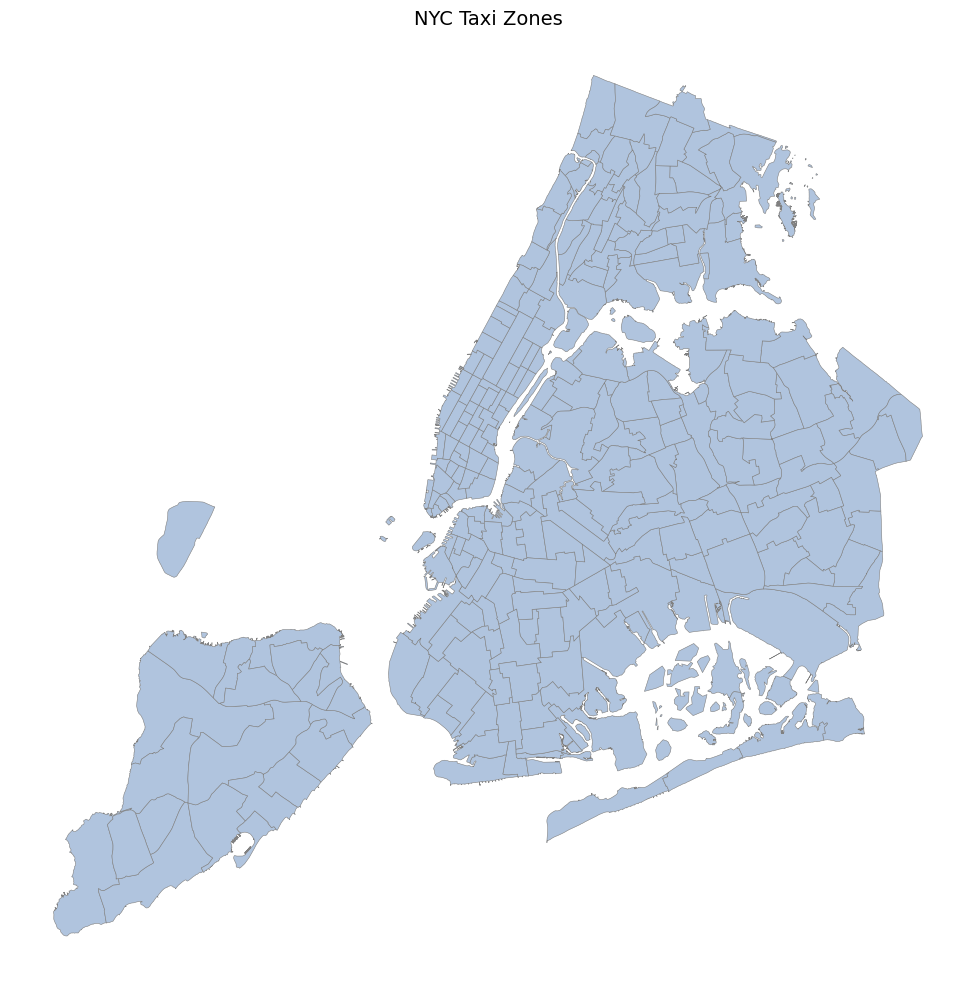

In [144]:
# print(zones.info())
# zones.plot()

# Display the base map of NYC taxi zones (Lets gooo!)
fig, ax = plt.subplots(figsize=(12, 10))
zones.plot(ax=ax, color='lightsteelblue', edgecolor='gray', linewidth=0.4)
ax.set_title('NYC Taxi Zones', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [145]:
# Merge zones and trip records using locationID and PULocationID
df_geo = df_nz.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

print(f'Shape after merge: {df_geo.shape}')
df_geo[['PULocationID', 'zone', 'borough']].head()


Shape after merge: (1808201, 27)


,PULocationID,zone,borough
0,163,Midtown North,Manhattan
1,161,Midtown Center,Manhattan
2,148,Lower East Side,Manhattan
3,161,Midtown Center,Manhattan
4,68,East Chelsea,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [146]:
# Group data by location and calculate the number of trips

# Count total trips per pickup zone
trips_per_zone = (
    df_nz.groupby('PULocationID')
    .size()
    .reset_index(name='num_trips')
    .sort_values('num_trips', ascending=False)
)

print('Top 10 pickup zones by trip count:')
print(trips_per_zone.head(10).to_string(index=False))

Top 10 pickup zones by trip count:
 PULocationID  num_trips
          132      94940
          237      86473
          161      85400
          236      77120
          162      65210
          138      63682
          186      62990
          230      60728
          142      60507
          170      54035


In [147]:
# Add zone names to make it readable
trips_per_zone_named = trips_per_zone.merge(
    zones[['LocationID', 'zone', 'borough']], 
    left_on='PULocationID', 
    right_on='LocationID'
)

print('Top 10 pickup zones:')
print(trips_per_zone_named.head(10)[['zone', 'borough', 'num_trips']].to_string(index=False))

Top 10 pickup zones:
                        zone   borough  num_trips
                 JFK Airport    Queens      94940
       Upper East Side South Manhattan      86473
              Midtown Center Manhattan      85400
       Upper East Side North Manhattan      77120
                Midtown East Manhattan      65210
           LaGuardia Airport    Queens      63682
Penn Station/Madison Sq West Manhattan      62990
   Times Sq/Theatre District Manhattan      60728
         Lincoln Square East Manhattan      60507
                 Murray Hill Manhattan      54035


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [148]:
# Merge trip counts back to the zones GeoDataFrame


zones_with_trips = zones.merge(
    trips_per_zone,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)
zones_with_trips['num_trips'] = zones_with_trips['num_trips'].fillna(0)

print(f'Shape: {zones_with_trips.shape}')
print(f'Zones with zero pickup: {(zones_with_trips["num_trips"] == 0).sum()}')


Shape: (263, 9)
Zones with zero pickup: 10


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

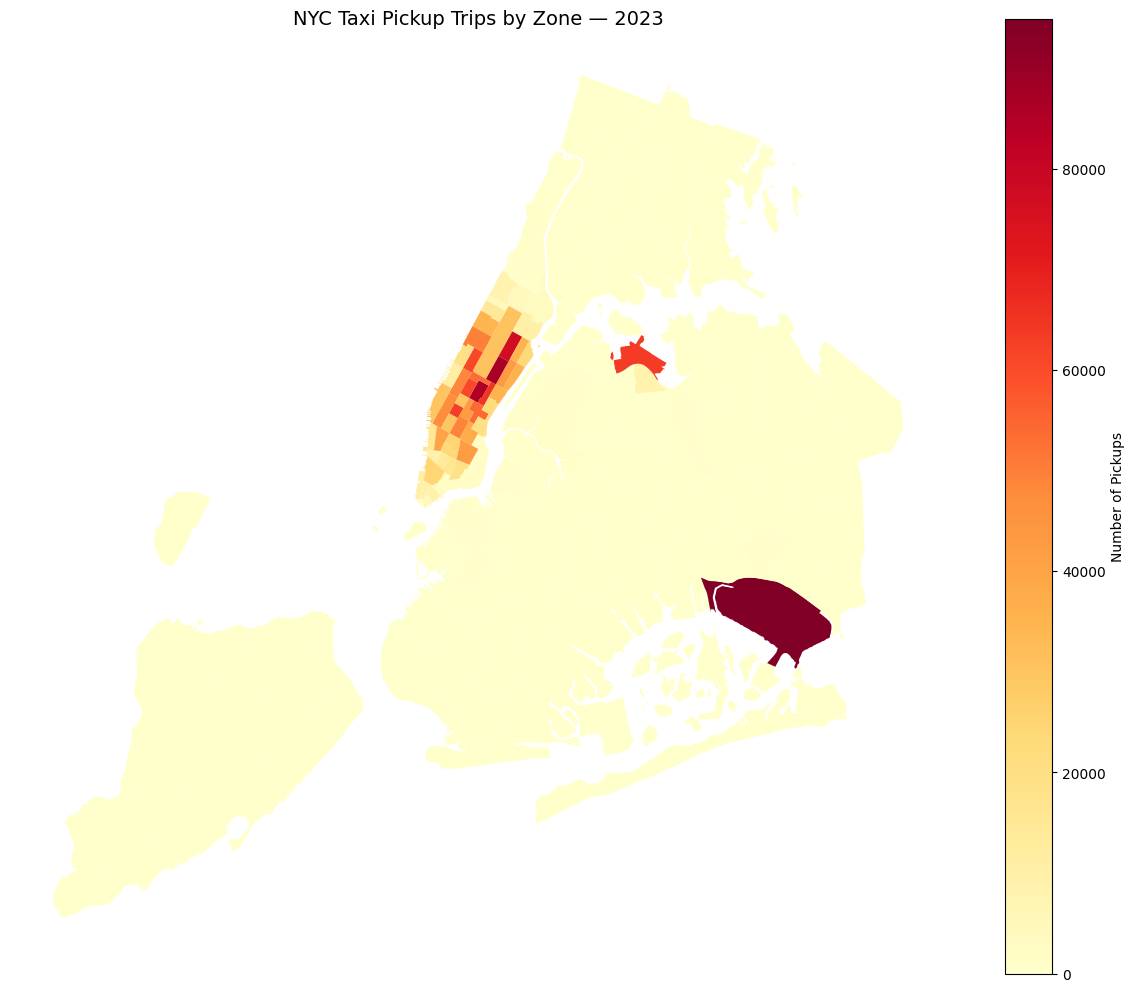

In [149]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column='num_trips',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Number of Pickups', 'orientation': 'vertical'}
)

ax.set_title('NYC Taxi Pickup Trips by Zone — 2023', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


In [152]:
# can you try displaying the zones DF sorted by the number of trips?

plt.close()

# Display zones sorted by number of trips
top_zones = (
    zones_with_trips[['zone', 'borough', 'num_trips']]
    .sort_values('num_trips', ascending=False)
)
print('Top 20 pickup zones:')
print(top_zones.head(20).to_string(index=False))

Top 20 pickup zones:
                        zone   borough  num_trips
                 JFK Airport    Queens    94940.0
       Upper East Side South Manhattan    86473.0
              Midtown Center Manhattan    85400.0
       Upper East Side North Manhattan    77120.0
                Midtown East Manhattan    65210.0
           LaGuardia Airport    Queens    63682.0
Penn Station/Madison Sq West Manhattan    62990.0
   Times Sq/Theatre District Manhattan    60728.0
         Lincoln Square East Manhattan    60507.0
                 Murray Hill Manhattan    54035.0
               Midtown North Manhattan    53411.0
       Upper West Side South Manhattan    50044.0
                    Union Sq Manhattan    49079.0
                Clinton East Manhattan    48355.0
                East Chelsea Manhattan    47363.0
             Lenox Hill West Manhattan    43200.0
                East Village Manhattan    42680.0
               Midtown South Manhattan    42391.0
                West Village 

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


## Summary of General EDA Findings

**Temporal Patterns:**
- Peak hour is 6 PM (evening rush), with demand rising steadily from 6 AM and dropping sharply after midnight.
- Thursday is the busiest weekday.
- Saturday sees elevted rides due to weekend rush.
- May recorded the highest monthly volume.
- Q4 generated the most revenue (26.83% of annual total), while Q3 was the lowest. (Holiday season peak?)

**Financial Insights:**
- Trip distance is the strongest predictor of fare amount (corelation: 0.9452), confirming distance-based pricing. (Naturally)
- Tip amount correlates moderately with fare (0.64), higher fares tend to attract better tips.
- The majority of surcharge columns (congestion, improvement) add small but consistent amounts to every trip.

**Payment Behaviour:**
- 81.5% of passengers pay by credit card, cash accounts for ~17%. (Post Covid realiness) 
- Tips are almost exclusively associated with credit card payments, cash tip data is largely missing/zero.

**Geographical Patterns:**
- JFK Airport is the #1 pickup zone, followed by other major transit hubs. (Not suprising at all)
- Manhattan zones dominate both pickups and drop-offs, reflecting the density of commercial and tourist activity.
- Outer boroughs (Bronx, Staten Island) account for a very small share of total trips.

**Key Takeaway:** NYC taxi demand is heavily concentrated in time (evening hours, weekdays) and space (Manhattan + airports). Revenue is distance-driven, and credit card is the dominant payment mode.


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [164]:
# Find routes which have the slowest speeds at different times of the day

df_new = df[df['trip_duration'].between(1, 180)]
df_new['avg_speed_mph'] = df_new['trip_distance'] / (df_new['trip_duration'] / 60)
df_new = df_new[df_new['avg_speed_mph'] <= 80]

route_speed = df_new.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('trip_duration', 'mean')
).reset_index()

route_speed['speed_mph'] = route_speed['avg_distance'] / (route_speed['avg_duration'] / 60)
route_speed = route_speed[route_speed['avg_distance'] > 0]

slowest = route_speed.sort_values('speed_mph').head(10)
print(slowest[['PULocationID', 'DOLocationID', 'pickup_hour', 'avg_distance', 'avg_duration', 'speed_mph']])

        PULocationID  DOLocationID  pickup_hour  avg_distance  avg_duration  \
91142            207           207           10        0.0005      1.469167   
121971           258           258            1        0.0200     45.750000   
90395            194           194           16        0.0100     12.266667   
9910              45            45           10        0.0500     50.433333   
43206            124           129           12        0.1000     83.300000   
50737            134           265           15        0.1000     81.266667   
17111             67           215           15        0.1000     76.833333   
24070             75           203           13        0.1000     63.433333   
110591           237             5           15        0.1000     63.133333   
30790             89           205           15        0.1000     62.500000   

        speed_mph  
91142    0.020420  
121971   0.026230  
90395    0.048913  
9910     0.059484  
43206    0.072029  
50737    0

In [165]:
route_speed = route_speed[route_speed['PULocationID'] != route_speed['DOLocationID']]
slowest = route_speed.sort_values('speed_mph').head(10)
print(slowest[['PULocationID', 'DOLocationID', 'pickup_hour', 'avg_distance', 'avg_duration', 'speed_mph']])

        PULocationID  DOLocationID  pickup_hour  avg_distance  avg_duration  \
43206            124           129           12          0.10     83.300000   
50737            134           265           15          0.10     81.266667   
17111             67           215           15          0.10     76.833333   
24070             75           203           13          0.10     63.433333   
110591           237             5           15          0.10     63.133333   
30790             89           205           15          0.10     62.500000   
94995            220           236           11          0.10     61.933333   
3756              18            74           10          0.10     51.500000   
6382              38           238            5          0.15     73.991667   
6787              41            46           10          0.10     48.766667   

        speed_mph  
43206    0.072029  
50737    0.073831  
17111    0.078091  
24070    0.094587  
110591   0.095037  
30790    0

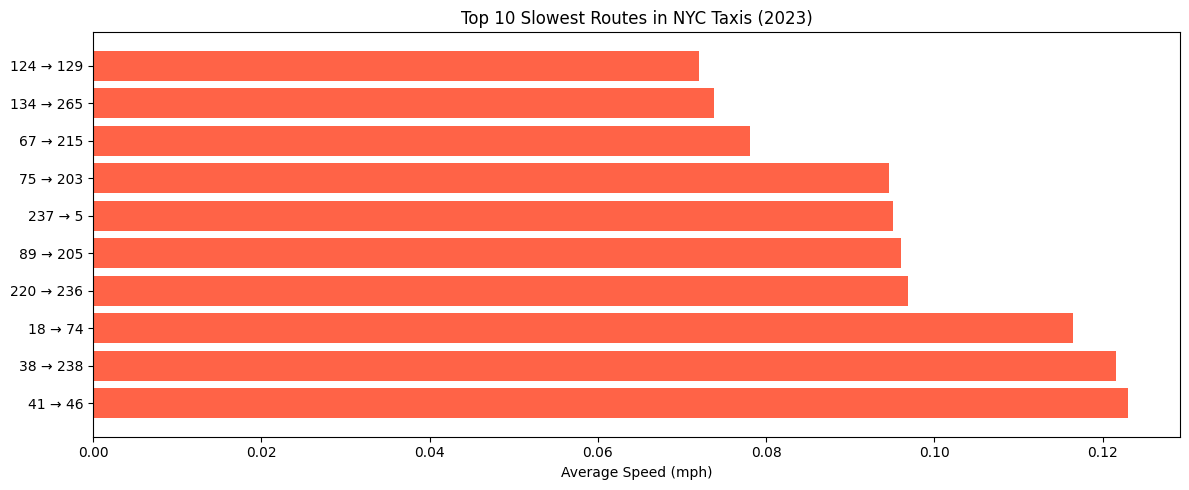

In [166]:
import matplotlib.pyplot as plt

slowest['route'] = slowest['PULocationID'].astype(str) + ' → ' + slowest['DOLocationID'].astype(str)

plt.figure(figsize=(12, 5))
plt.barh(slowest['route'], slowest['speed_mph'], color='tomato')
plt.xlabel('Average Speed (mph)')
plt.title('Top 10 Slowest Routes in NYC Taxis (2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

pickup_hour        18
trip_count     127990
Name: 18, dtype: int64


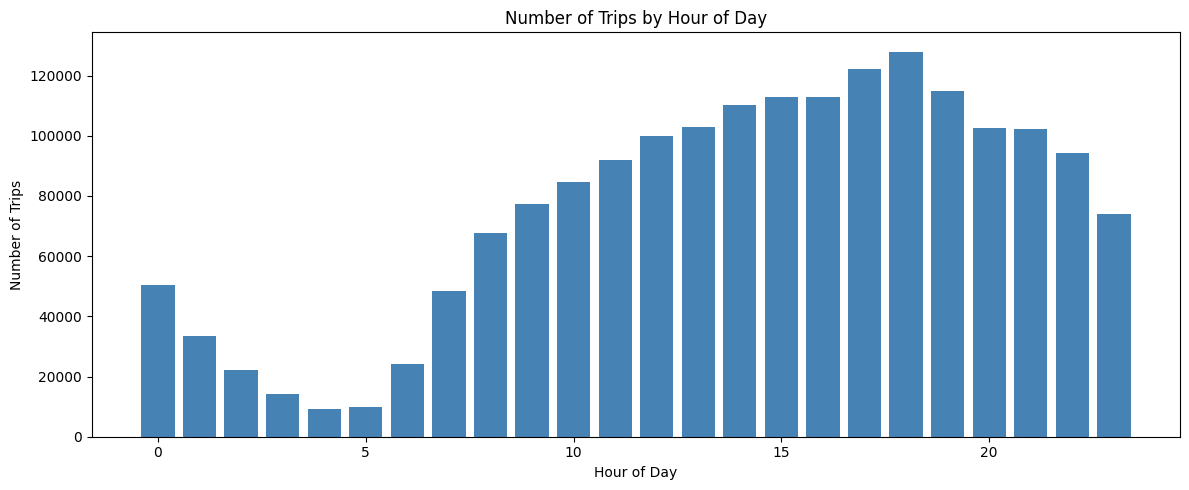

In [167]:
# Visualise the number of trips per hour and find the busiest hour

# Count trips per hr
hourly_trips = df_new.groupby('pickup_hour').size().reset_index()
hourly_trips.columns = ['pickup_hour', 'trip_count']

# Find busiest hr
busiest_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]
print(busiest_hour)

# Let's Visualize
plt.figure(figsize=(12, 5))
plt.bar(hourly_trips['pickup_hour'], hourly_trips['trip_count'], color='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Hour of Day')
plt.tight_layout()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [169]:
# Scale up the number of trips
sample_fraction = 0.05
top5_hours = hourly_trips.sort_values('trip_count', ascending=False).head(5)
top5_hours['actual_trips'] = (top5_hours['trip_count'] / sample_fraction).astype(int)
print(top5_hours[['pickup_hour', 'trip_count', 'actual_trips']])
# Fill in the value of your sampling fraction and use that to scale up the numbers




    pickup_hour  trip_count  actual_trips
18           18      127990       2559800
17           17      122227       2444540
19           19      114877       2297540
15           15      112968       2259360
16           16      112764       2255280


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

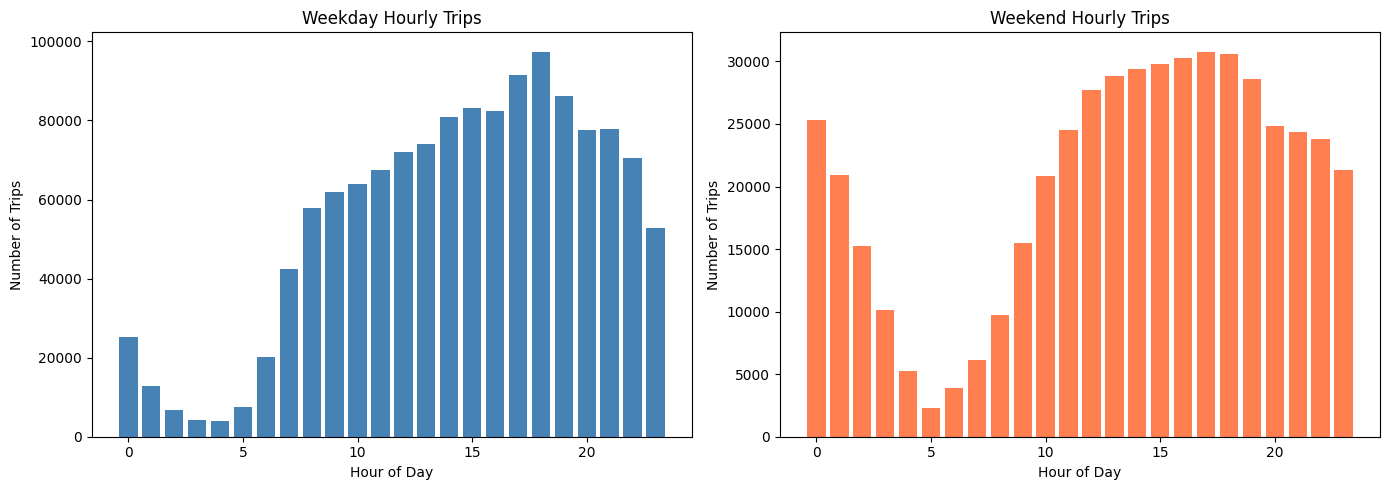

In [170]:
# Compare traffic trends for the week days and weekends

# Split into weekday and weekend
weekday_df = df_new[df_new['pickup_day_of_week'] < 5]
weekend_df = df_new[df_new['pickup_day_of_week'] >= 5]

# Count trips per hour
weekday_hourly = weekday_df.groupby('pickup_hour').size().reset_index(name='trip_count')
weekend_hourly = weekend_df.groupby('pickup_hour').size().reset_index(name='trip_count')

# Lets Visualize n see
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(weekday_hourly['pickup_hour'], weekday_hourly['trip_count'], color='steelblue')
axes[0].set_title('Weekday Hourly Trips')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trips')

axes[1].bar(weekend_hourly['pickup_hour'], weekend_hourly['trip_count'], color='coral')
axes[1].set_title('Weekend Hourly Trips')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

- Weekdays show a sharp peak at 6 PM (evening rush hour), with demand building steadily from 7 AM. Early mornings (2–5 AM) are the quietest.
- Weekends have a flatter, broader peak between 12 PM and 8 PM, people are out for leisure not commuting. No sharp morning rush.
- Knowing busy vs quiet hours helps operators deploy more cabs at peak times and reduce idle cabs during off-peak hours, saving costs and improving service.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

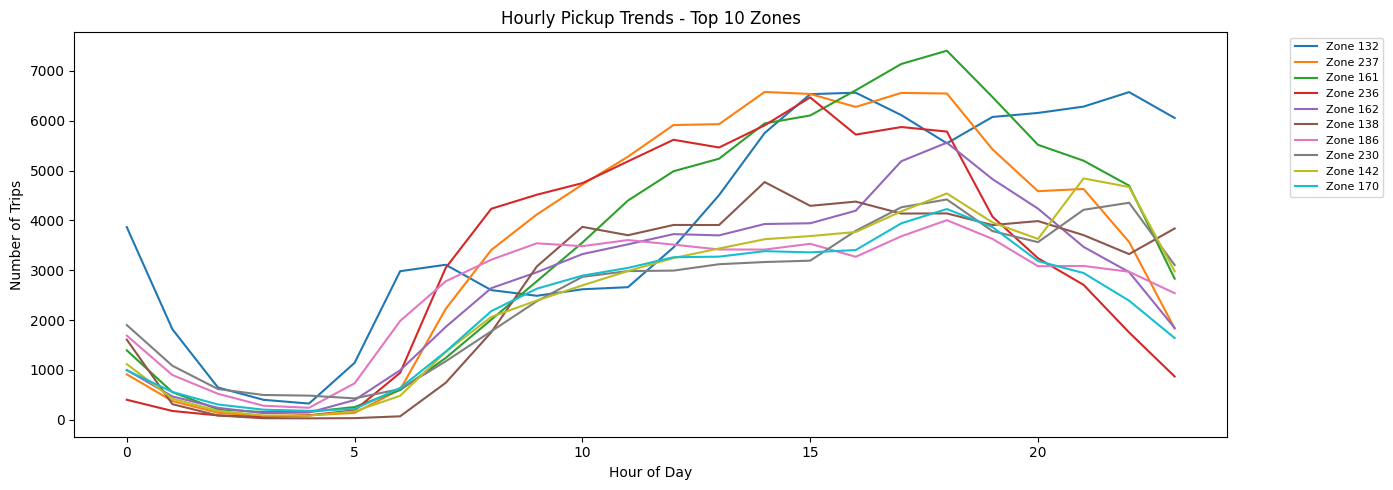

In [172]:
# Find top 10 pickup and dropoff zones

# Hourly trends for top 10 pickup zones
top_pu_zones = top_pickup['PULocationID'].tolist()
pu_hourly = df_new[df_new['PULocationID'].isin(top_pu_zones)].groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='trip_count')

plt.figure(figsize=(14, 5))
for zone in top_pu_zones:
    data = pu_hourly[pu_hourly['PULocationID'] == zone]
    plt.plot(data['pickup_hour'], data['trip_count'], label=f'Zone {zone}')
plt.title('Hourly Pickup Trends - Top 10 Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

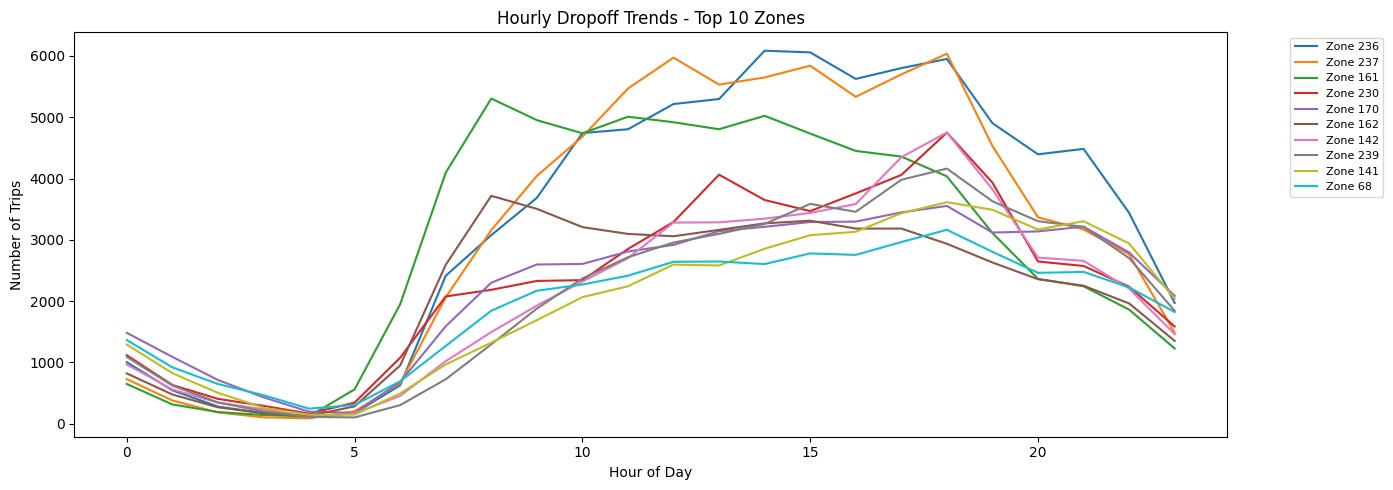

In [173]:
# Hourly trends for top 10 dropoff zones
top_do_zones = top_dropoff['DOLocationID'].tolist()
do_hourly = df_new[df_new['DOLocationID'].isin(top_do_zones)].groupby(['DOLocationID', 'pickup_hour']).size().reset_index(name='trip_count')

plt.figure(figsize=(14, 5))
for zone in top_do_zones:
    data = do_hourly[do_hourly['DOLocationID'] == zone]
    plt.plot(data['pickup_hour'], data['trip_count'], label=f'Zone {zone}')
plt.title('Hourly Dropoff Trends - Top 10 Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

Top 10 zones (more pickups than dropoffs):
     zone  pickups  dropoffs     ratio
68     70     8046       821  9.800244
124   132    94261     18641  5.056649
130   138    63576     21587  2.945106
177   186    63072     39753  1.586597
41     43    30589     22224  1.376395
106   114    23948     17412  1.375373
237   249    40158     30246  1.327713
154   162    65227     51884  1.257170
153   161    85431     71167  1.200430
97    100    29955     25105  1.193189

Bottom 10 zones (more dropoffs than pickups):
     zone  pickups  dropoffs     ratio
0       1       16      5125  0.003122
26     27        1        39  0.025641
245   257       22       755  0.029139
120   128        4       107  0.037383
253   265      276      7072  0.039027
107   115        1        23  0.043478
104   112      178      3931  0.045281
189   198       45       977  0.046059
35     37       91      1794  0.050725
94     96        3        59  0.050847


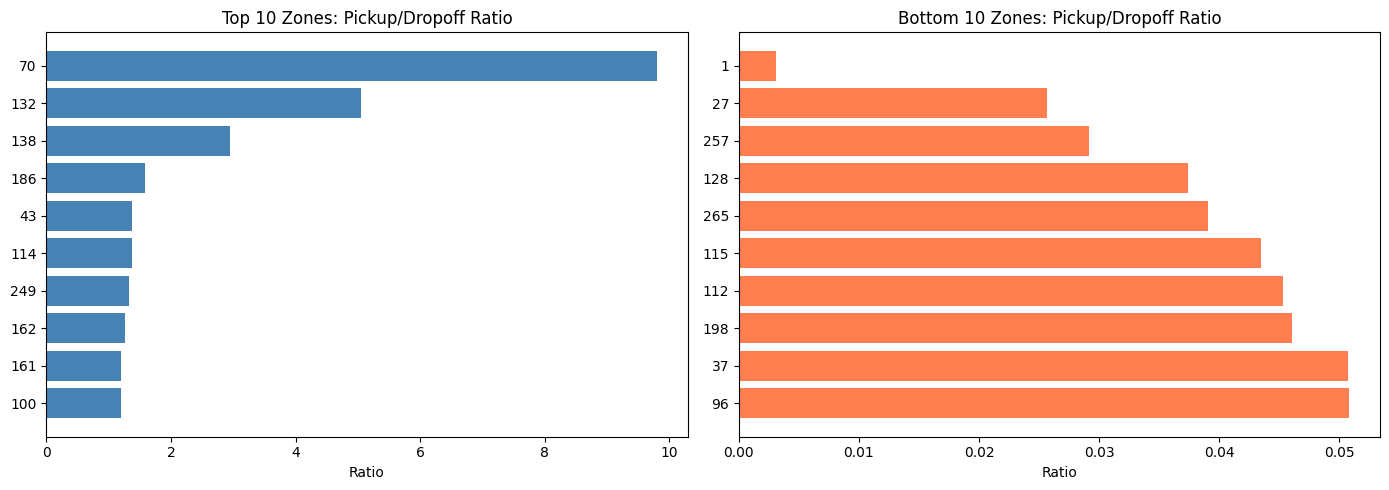

In [175]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pu_counts = df_new.groupby('PULocationID').size().reset_index(name='pickups')
do_counts = df_new.groupby('DOLocationID').size().reset_index(name='dropoffs')

ratio_df = pu_counts.merge(do_counts, left_on='PULocationID', right_on='DOLocationID')
ratio_df['ratio'] = ratio_df['pickups'] / ratio_df['dropoffs']
ratio_df = ratio_df[['PULocationID', 'pickups', 'dropoffs', 'ratio']].rename(columns={'PULocationID': 'zone'})

top10 = ratio_df.sort_values('ratio', ascending=False).head(10)
bottom10 = ratio_df.sort_values('ratio').head(10)

print("Top 10 zones (more pickups than dropoffs):")
print(top10)
print("\nBottom 10 zones (more dropoffs than pickups):")
print(bottom10)

#Lets Visualize it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10['zone'].astype(str), top10['ratio'], color='steelblue')
axes[0].set_title('Top 10 Zones: Pickup/Dropoff Ratio')
axes[0].set_xlabel('Ratio')
axes[0].invert_yaxis()

axes[1].barh(bottom10['zone'].astype(str), bottom10['ratio'], color='coral')
axes[1].set_title('Bottom 10 Zones: Pickup/Dropoff Ratio')
axes[1].set_xlabel('Ratio')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

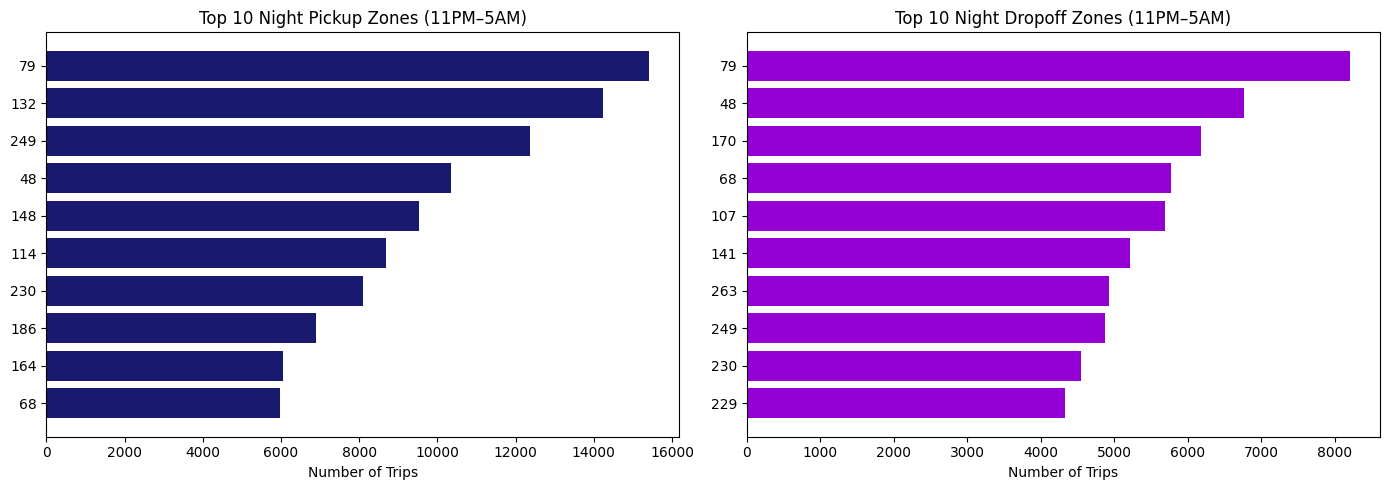

In [176]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df_new[(df_new['pickup_hour'] >= 23) | (df_new['pickup_hour'] <= 5)]

night_pickup = night_df.groupby('PULocationID').size().sort_values(ascending=False).head(10).reset_index(name='trip_count')
night_dropoff = night_df.groupby('DOLocationID').size().sort_values(ascending=False).head(10).reset_index(name='trip_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(night_pickup['PULocationID'].astype(str), night_pickup['trip_count'], color='midnightblue')
axes[0].set_title('Top 10 Night Pickup Zones (11PM–5AM)')
axes[0].set_xlabel('Number of Trips')
axes[0].invert_yaxis()

axes[1].barh(night_dropoff['DOLocationID'].astype(str), night_dropoff['trip_count'], color='darkviolet')
axes[1].set_title('Top 10 Night Dropoff Zones (11PM–5AM)')
axes[1].set_xlabel('Number of Trips')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night revenue: $6,238,639.79 (11.99%)
Day revenue:   $45,801,701.12 (88.01%)


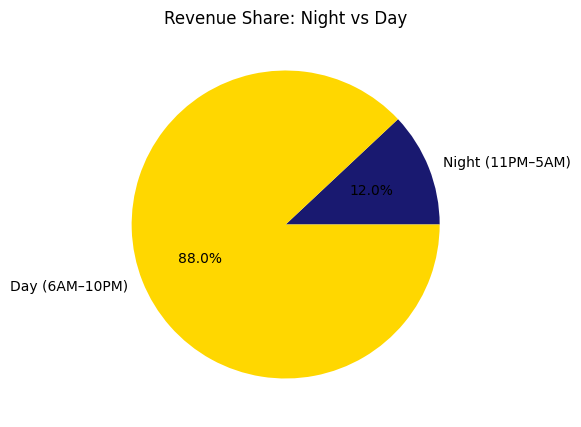

In [177]:
# Filter for night hours (11 PM to 5 AM)

night = df_new[(df_new['pickup_hour'] >= 23) | (df_new['pickup_hour'] <= 5)]
day = df_new[(df_new['pickup_hour'] > 5) & (df_new['pickup_hour'] < 23)]

night_revenue = night['total_amount'].sum()
day_revenue = day['total_amount'].sum()
total_revenue = night_revenue + day_revenue

print(f"Night revenue: ${night_revenue:,.2f} ({night_revenue/total_revenue*100:.2f}%)")
print(f"Day revenue:   ${day_revenue:,.2f} ({day_revenue/total_revenue*100:.2f}%)")

plt.figure(figsize=(6, 5))
plt.pie([night_revenue, day_revenue], labels=['Night (11PM–5AM)', 'Day (6AM–10PM)'],
        autopct='%1.1f%%', colors=['midnightblue', 'gold'])
plt.title('Revenue Share: Night vs Day')
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

   passenger_count  avg_fare_per_mile  fare_per_mile_per_pax
0                1           7.810912               7.810912
1                2           7.610785               3.805393
2                3           7.753499               2.584500
3                4           7.710105               1.927526
4                5           7.620845               1.524169
5                6           7.716818               1.286136


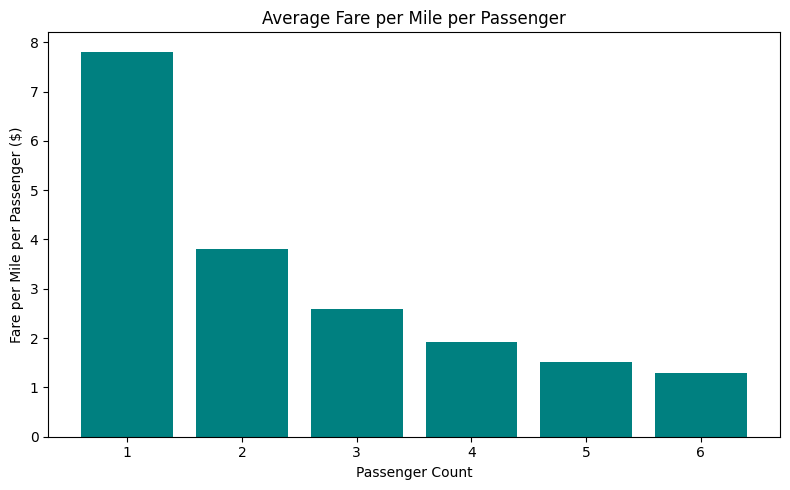

In [178]:
# Analyse the fare per mile per passenger for different passenger counts

df_new['fare_per_mile'] = df_new['fare_amount'] / df_new['trip_distance']
df_new = df_new[df_new['fare_per_mile'] < 50]  # remove extreme outliers

fare_per_pax = df_new.groupby('passenger_count').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()

fare_per_pax['fare_per_mile_per_pax'] = fare_per_pax['avg_fare_per_mile'] / fare_per_pax['passenger_count']

print(fare_per_pax)

plt.figure(figsize=(8, 5))
plt.bar(fare_per_pax['passenger_count'].astype(str), fare_per_pax['fare_per_mile_per_pax'], color='teal')
plt.title('Average Fare per Mile per Passenger')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger ($)')
plt.tight_layout()
plt.show()



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

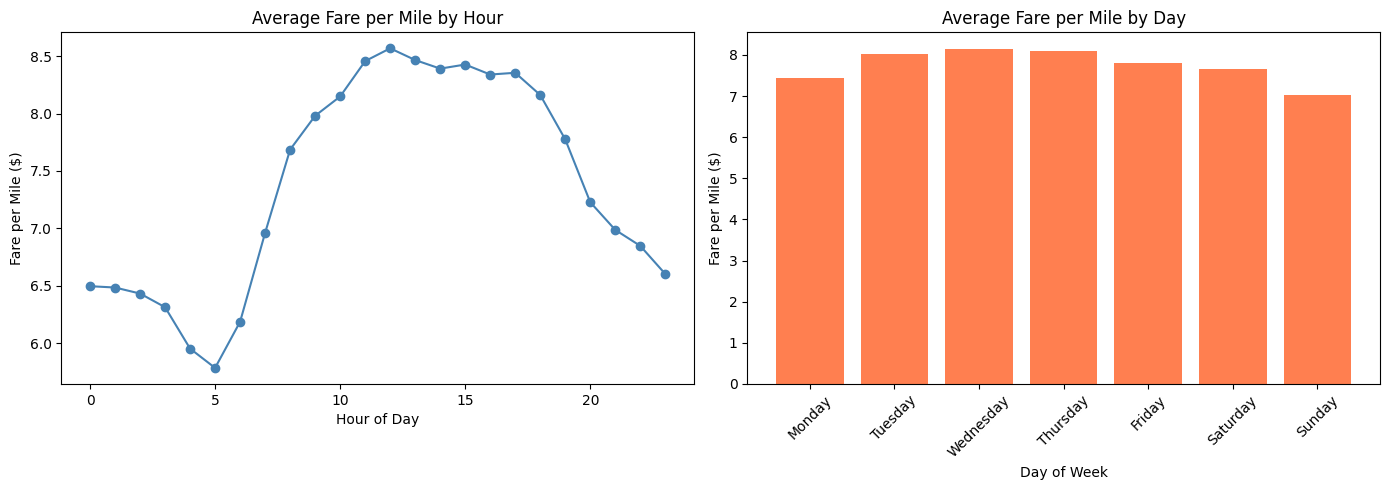

In [179]:
# Compare the average fare per mile for different days and for different times of the day


hourly_fare = df_new.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()
daily_fare = df_new.groupby('pickup_day_name')['fare_per_mile'].mean().reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fare['pickup_day_name'] = pd.Categorical(daily_fare['pickup_day_name'], categories=day_order, ordered=True)
daily_fare = daily_fare.sort_values('pickup_day_name')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_fare['pickup_hour'], hourly_fare['fare_per_mile'], marker='o', color='steelblue')
axes[0].set_title('Average Fare per Mile by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fare per Mile ($)')

axes[1].bar(daily_fare['pickup_day_name'], daily_fare['fare_per_mile'], color='coral')
axes[1].set_title('Average Fare per Mile by Day')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fare per Mile ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

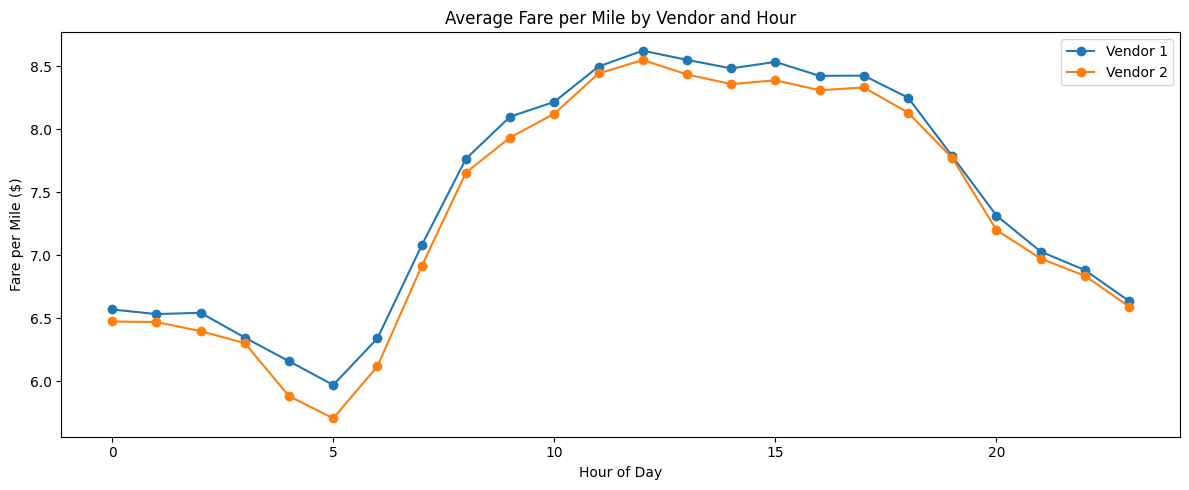

In [180]:
# Compare fare per mile for different vendors

vendor_hourly = df_new.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 5))
for vendor in vendor_hourly['VendorID'].unique():
    data = vendor_hourly[vendor_hourly['VendorID'] == vendor]
    plt.plot(data['pickup_hour'], data['fare_per_mile'], marker='o', label=f'Vendor {int(vendor)}')

plt.title('Average Fare per Mile by Vendor and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fare per Mile ($)')
plt.legend()
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


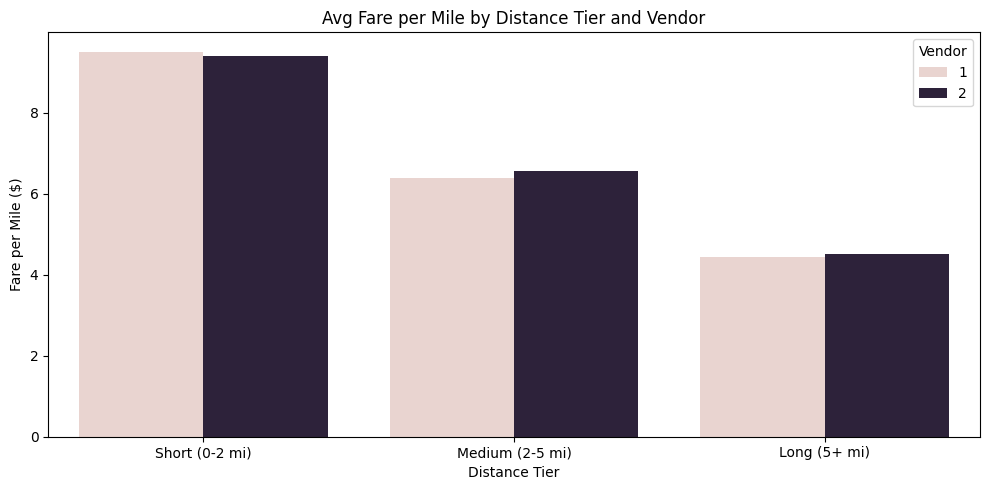

     distance_tier  VendorID  fare_per_mile
0   Short (0-2 mi)         1       9.504471
1   Short (0-2 mi)         2       9.398262
2  Medium (2-5 mi)         1       6.379543
3  Medium (2-5 mi)         2       6.546700
4     Long (5+ mi)         1       4.427217
5     Long (5+ mi)         2       4.501766


In [181]:
# Defining distance tiers

df_new['distance_tier'] = pd.cut(df_new['trip_distance'],
                                  bins=[0, 2, 5, float('inf')],
                                  labels=['Short (0-2 mi)', 'Medium (2-5 mi)', 'Long (5+ mi)'])

tier_vendor = df_new.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().reset_index()

import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(data=tier_vendor, x='distance_tier', y='fare_per_mile', hue='VendorID')
plt.title('Avg Fare per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Fare per Mile ($)')
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

print(tier_vendor)

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

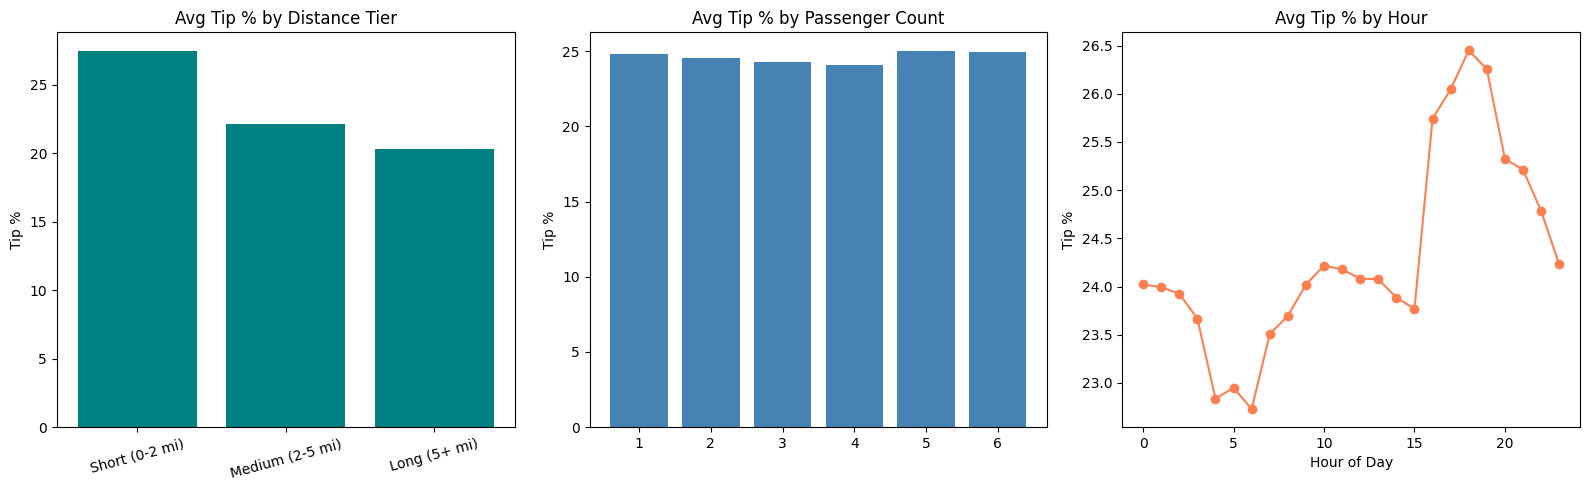

In [182]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

cc_df = df_new[df_new['payment_type'] == 1].copy()
cc_df['tip_pct'] = (cc_df['tip_amount'] / cc_df['fare_amount']) * 100
cc_df = cc_df[cc_df['tip_pct'] <= 100]

# By distance tier
tip_by_dist = cc_df.groupby('distance_tier')['tip_pct'].mean().reset_index()
# By passenger count
tip_by_pax = cc_df.groupby('passenger_count')['tip_pct'].mean().reset_index()
# By hour
tip_by_hour = cc_df.groupby('pickup_hour')['tip_pct'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(tip_by_dist['distance_tier'], tip_by_dist['tip_pct'], color='teal')
axes[0].set_title('Avg Tip % by Distance Tier')
axes[0].set_ylabel('Tip %')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(tip_by_pax['passenger_count'].astype(str), tip_by_pax['tip_pct'], color='steelblue')
axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_ylabel('Tip %')

axes[2].plot(tip_by_hour['pickup_hour'], tip_by_hour['tip_pct'], marker='o', color='coral')
axes[2].set_title('Avg Tip % by Hour')
axes[2].set_ylabel('Tip %')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [183]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip = cc_df[cc_df['tip_pct'] < 10]
high_tip = cc_df[cc_df['tip_pct'] > 25]

comparison = pd.DataFrame({
    'Metric': ['Avg Trip Distance (mi)', 'Avg Fare ($)', 'Avg Passenger Count', 'Avg Duration (min)'],
    'Low Tip (<10%)': [
        low_tip['trip_distance'].mean(),
        low_tip['fare_amount'].mean(),
        low_tip['passenger_count'].mean(),
        low_tip['trip_duration'].mean()
    ],
    'High Tip (>25%)': [
        high_tip['trip_distance'].mean(),
        high_tip['fare_amount'].mean(),
        high_tip['passenger_count'].mean(),
        high_tip['trip_duration'].mean()
    ]
})

print(comparison.to_string(index=False))

                Metric  Low Tip (<10%)  High Tip (>25%)
Avg Trip Distance (mi)        4.884358         2.304278
          Avg Fare ($)       25.562559        14.409974
   Avg Passenger Count        1.377393         1.363409
    Avg Duration (min)       21.409967        12.265365


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

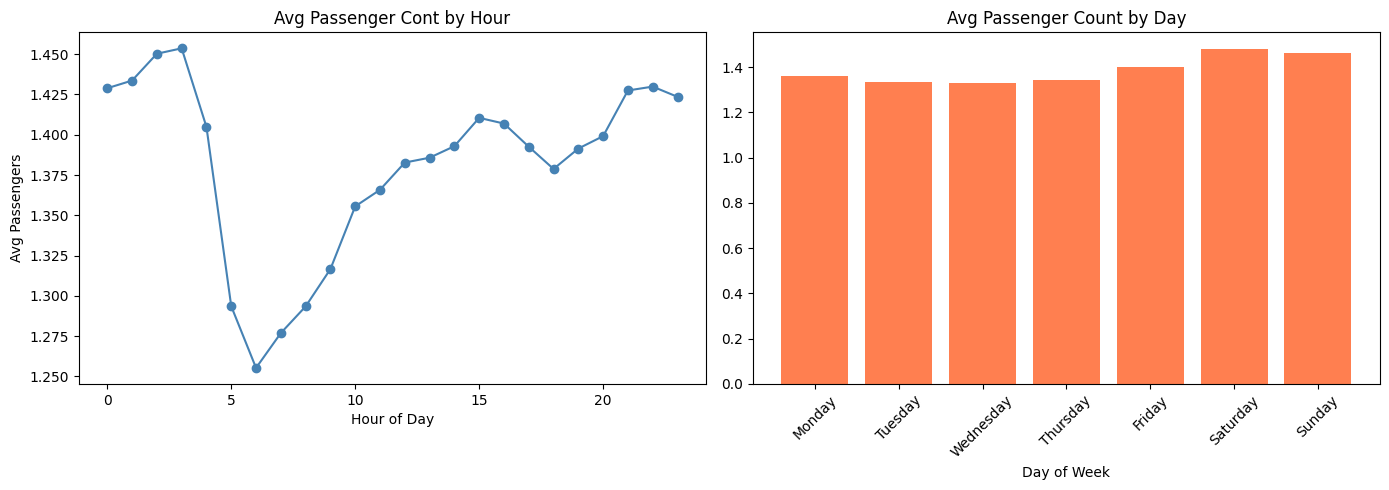

In [184]:
# See how passenger count varies across hours and days


pax_by_hour = df_new.groupby('pickup_hour')['passenger_count'].mean().reset_index()
pax_by_day = df_new.groupby('pickup_day_name')['passenger_count'].mean().reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pax_by_day['pickup_day_name'] = pd.Categorical(pax_by_day['pickup_day_name'], categories=day_order, ordered=True)
pax_by_day = pax_by_day.sort_values('pickup_day_name')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pax_by_hour['pickup_hour'], pax_by_hour['passenger_count'], marker='o', color='steelblue')
axes[0].set_title('Avg Passenger Cont by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Passengers')

axes[1].bar(pax_by_day['pickup_day_name'], pax_by_day['passenger_count'], color='coral')
axes[1].set_title('Avg Passenger Count by Day')
axes[1].set_xlabel('Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [185]:
# How does passenger count vary across zones

pax_by_zone = df_new.groupby('PULocationID')['passenger_count'].mean().reset_index()
pax_by_zone.columns = ['LocationID', 'avg_passenger_count']

top_pax_zones = pax_by_zone.sort_values('avg_passenger_count', ascending=False).head(10)
print(top_pax_zones)

     LocationID  avg_passenger_count
185         195             1.870056
11           12             1.741016
197         207             1.714286
119         128             1.666667
55           58             1.666667
168         178             1.625000
184         194             1.600000
63           66             1.581609
31           34             1.565217
249         261             1.543637


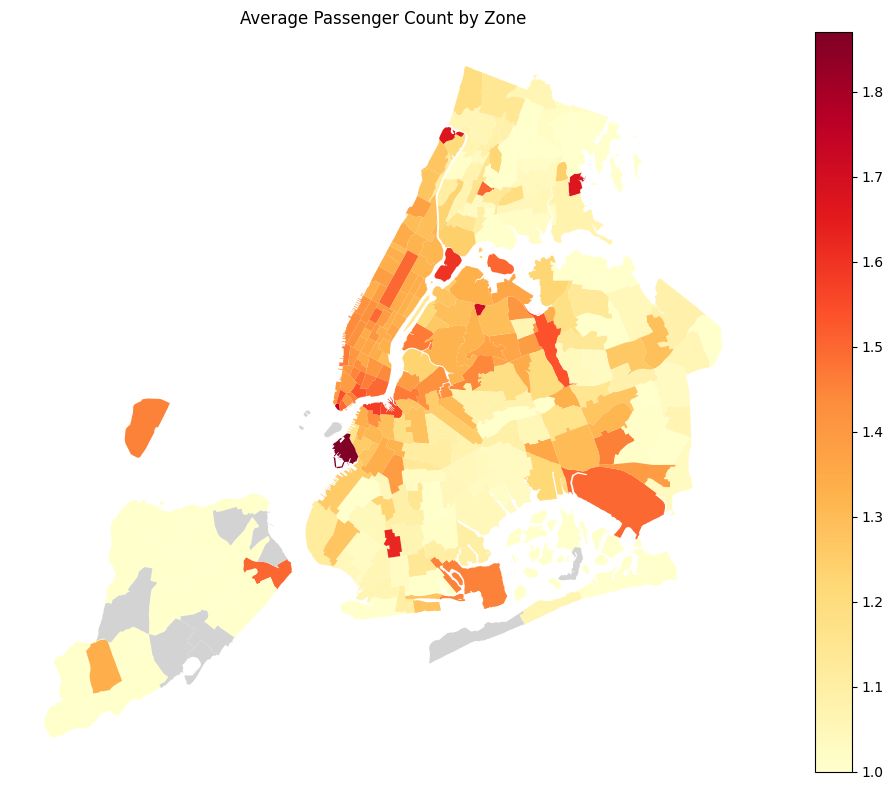

In [186]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_gdf = gpd.read_file('datasets/taxi_zones/taxi_zones.shp')
zones_gdf['LocationID'] = zones_gdf['LocationID'].astype(int)
pax_by_zone['LocationID'] = pax_by_zone['LocationID'].astype(int)

zones_with_pax = zones_gdf.merge(pax_by_zone, on='LocationID', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
zones_with_pax.plot(column='avg_passenger_count', ax=ax, legend=True, cmap='YlOrRd', missing_kwds={'color': 'lightgrey'})
ax.set_title('Average Passenger Count by Zone')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

               Surcharge  Frequency (%)
0                  extra      62.411637
1                mta_tax      99.437969
2  improvement_surcharge      99.995551
3   congestion_surcharge      93.071052
4            airport_fee       8.765418


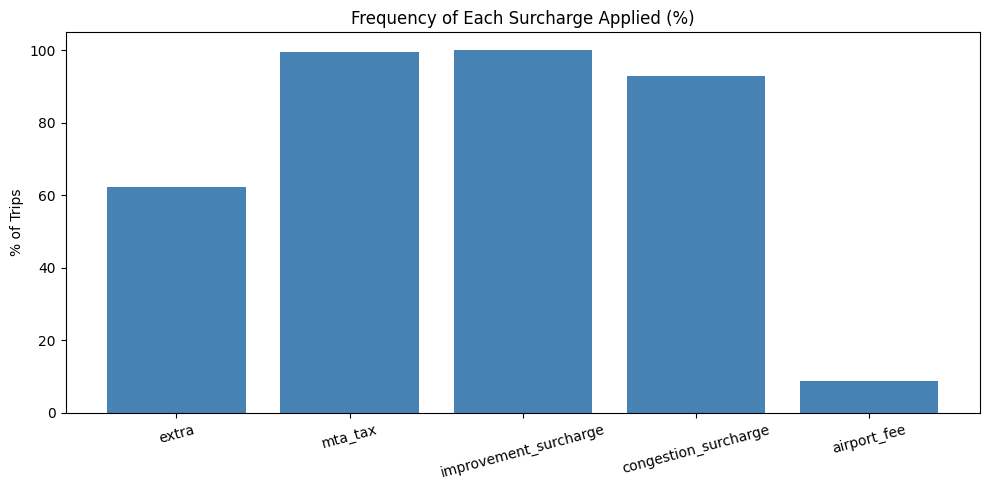

In [187]:
# How often is each surcharge applied?


surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

surcharge_freq = {}
for col in surcharge_cols:
    surcharge_freq[col] = (df_new[col] > 0).sum() / len(df_new) * 100

surcharge_df = pd.DataFrame(list(surcharge_freq.items()), columns=['Surcharge', 'Frequency (%)'])
print(surcharge_df)

plt.figure(figsize=(10, 5))
plt.bar(surcharge_df['Surcharge'], surcharge_df['Frequency (%)'], color='steelblue')
plt.title('Frequency of Each Surcharge Applied (%)')
plt.ylabel('% of Trips')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

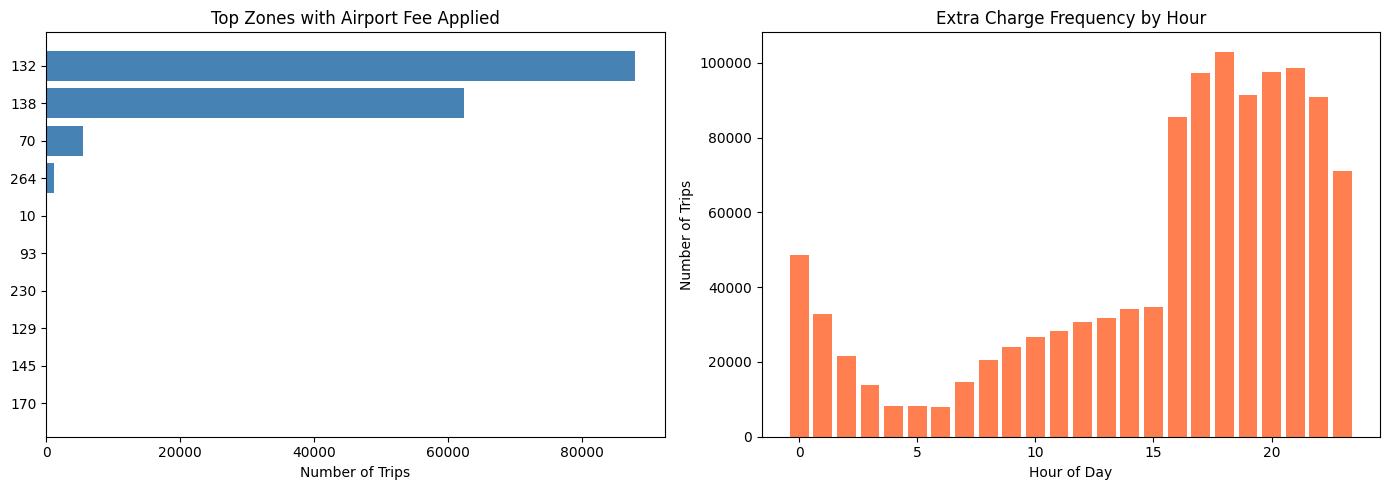

In [188]:
# Zones with highest airport fee frequency
airport_zones = df_new[df_new['airport_fee'] > 0].groupby('PULocationID').size().sort_values(ascending=False).head(10).reset_index(name='count')

# Hours with highest extra charge frequency  
extra_hours = df_new[df_new['extra'] > 0].groupby('pickup_hour').size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(airport_zones['PULocationID'].astype(str), airport_zones['count'], color='steelblue')
axes[0].set_title('Top Zones with Airport Fee Applied')
axes[0].set_xlabel('Number of Trips')
axes[0].invert_yaxis()

axes[1].bar(extra_hours['pickup_hour'], extra_hours['count'], color='coral')
axes[1].set_title('Extra Charge Frequency by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

My analysis reveals that NYC taxi demand peaks sharply at 6 PM on weekdays, with Thursday being the busiest day. 
Slowest routes are concentrated during midday (12–3 PM) on short inner-city routes, suggesting severe traffic congestion rather than long distances.

Recommendations:
- Pre-position cabs in Midtown and Upper East Side zones by 4:30 PM to capture the evening rush before demand peaks.
- De-prioritise short inner-city dispatches during 12–3 PM when average speeds drop below 1 mph on several routes then redirect drivers to faster outer-borough or highway routes.
- At night (11 PM–5 AM), algorithmic dispatch should favour Zone 79 (East Village) and Zone 132 (JFK Airport), which account for the highest night trip volumes. JFK has the most congestion as seen in the analysis.
- Early morning hours (2–4 AM) carry more passengers per trip, larger capacity vehicles or group ride options could be offered during this window.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Manhattan dominates both pickups and dropoffs, but airport zones show a severe imbalance:
- JFK Airport (Zone 132) has a pickup/dropoff ratio of 5:1, cabs flood in for pickups but rarely receive drop-offs there.
- Newark (Zone 1) shows the opposite: almost no pickups but heavy drop-offs, creating dead miles for drivers returning to the city.

Recommendations:
- Deploy dedicated airport queues at JFK and LaGuardia during morning and evening flight peaks to reduce idle waiting time as that would save up so much time and traffic.
- Incentivise drivers dropping off at low-pickup zones (Newark, Zone 265) to reposition quickly to high-demand Manhattan zones rather than waiting locally.
- On weekends, shift supply southward toward entertainment districts in Lower Manhattan and Midtown from noon onward, as leisure demand builds through the afternoon and peaks later on the day.
- Outer boroughs (Bronx, Staten Island) are consistently underserved, a targeted coverage strategy could open a new demand segment which could be monitarily benificial.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Both vendors charge nearly identical fares across all distance tiers and hours, indicating 
no meaningful price competition. Short trips under 2 miles cost 9.50 dollars per mile while long trips over 5 miles cost only $4.43/mile, a 2x gap driven by the fixed base fare structure.

Recommendations:
- Introduce mild surge pricing (10–15% uplift) during peak hours (5–7 PM weekdays) when demand consistently exceeds supply, data shows 127,990 trips in the 6 PM hour alone. A very high peak time during the day.
- Short trips are already high-margin per mile. A minimum fare floor would protect revenue on very short rides without deterring customers significantly.
- Night trips generate only 12% of annual revenue despite comprising a meaningful share of volume, a driver night bonus could grow supply in this underserved window and cause a win-win situtation.
- Group rides for 3+ passengers currently pay $1.29/mile per person by creating a formalised group discount of 10–15% it could stimulate demand during midday off-peak hours without hurting overall revenue. Who doesn't love discounts?